## Assignment 1 - COMP9414
## By Pulkit Jain - z5708011

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib

print("Python path:", sys.executable)
print("All imports successful")

Python path: /Users/pulkitjain/Documents/Documents - Pulkit's MacBook Pro/UNSW Study/Term 1/COMP9414/Assignment 1/.venv/bin/python
All imports successful


In [2]:
from pathlib import Path
import glob

BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / "datasets"
FIG_DIR = BASE_DIR / "figures"
SCALER_DIR = BASE_DIR / "scalers"
OUTPUT_DIR = BASE_DIR / "outputs"
MODEL_DIR = BASE_DIR / "models"

for folder in [FIG_DIR, SCALER_DIR, OUTPUT_DIR, MODEL_DIR]:
    folder.mkdir(exist_ok=True)

print("Project folders ready.")

Project folders ready.


In [3]:
csv_files = sorted(glob.glob(str(DATA_DIR / "daily_solar_*.csv")))

print("Number of files:", len(csv_files))

dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)

solar_df = pd.concat(dfs, ignore_index=True)

solar_df["date"] = pd.to_datetime(solar_df["date"])
solar_df = solar_df.sort_values("date")

print("Dataset shape:", solar_df.shape)

solar_df.head()

Number of files: 18
Dataset shape: (6575, 3)


,date,solar_t,bad_quality
0,1996-01-01,35.675000,0
1,1996-01-02,105.147917,0
2,1996-01-03,100.647917,0
3,1996-01-04,30.275000,0
4,1996-01-05,92.141962,0


In [4]:
print("Columns:")
print(solar_df.columns)

print("\nDate Range:")
print(solar_df["date"].min(), "to", solar_df["date"].max())

print("\nBad quality counts:")
print(solar_df["bad_quality"].value_counts())

Columns:
Index(['date', 'solar_t', 'bad_quality'], dtype='str')

Date Range:
1996-01-01 00:00:00 to 2013-12-31 00:00:00

Bad quality counts:
bad_quality
0    5570
1    1005
Name: count, dtype: int64


In [5]:
total_rows = len(solar_df)

bad_rows = (solar_df["bad_quality"] == 1).sum()

clean_df = solar_df[solar_df["bad_quality"] == 0].copy()

removed_pct = (bad_rows / total_rows) * 100

print("Total rows:", total_rows)
print("Bad rows removed:", bad_rows)
print("Remaining rows:", len(clean_df))
print(f"Percentage removed: {removed_pct:.2f}%")

Total rows: 6575
Bad rows removed: 1005
Remaining rows: 5570
Percentage removed: 15.29%


## Part A — Data Preprocessing

- Load and Clean Data
- Fourier Cyclical Encoding
- Rolling Statistics
- Lagged Features
- Target Variables
- Scaling
- Visualisation

In [6]:
solar_df = solar_df.sort_values("date").reset_index(drop=True)
clean_df = clean_df.sort_values("date").reset_index(drop=True)

print("solar_df shape:", solar_df.shape)
print("clean_df shape:", clean_df.shape)
clean_df.head()

solar_df shape: (6575, 3)
clean_df shape: (5570, 3)


,date,solar_t,bad_quality
0,1996-01-01,35.675000,0
1,1996-01-02,105.147917,0
2,1996-01-03,100.647917,0
3,1996-01-04,30.275000,0
4,1996-01-05,92.141962,0


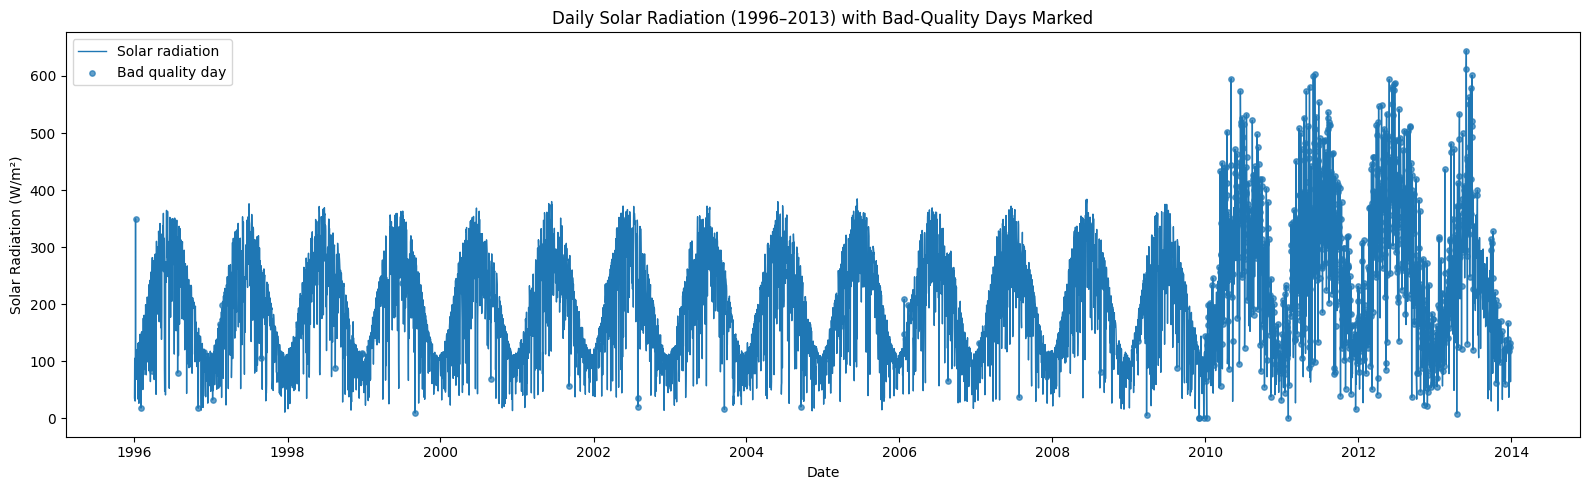

In [7]:
plt.figure(figsize=(16, 5))

plt.plot(
    solar_df["date"],
    solar_df["solar_t"],
    linewidth=1,
    label="Solar radiation"
)

bad_df = solar_df[solar_df["bad_quality"] == 1]

plt.scatter(
    bad_df["date"],
    bad_df["solar_t"],
    s=15,
    alpha=0.7,
    label="Bad quality day"
)

plt.title("Daily Solar Radiation (1996–2013) with Bad-Quality Days Marked")
plt.xlabel("Date")
plt.ylabel("Solar Radiation (W/m²)")
plt.legend()
plt.tight_layout()

plt.savefig(FIG_DIR / "partA_timeseries_bad_quality.png", dpi=200)
plt.show()

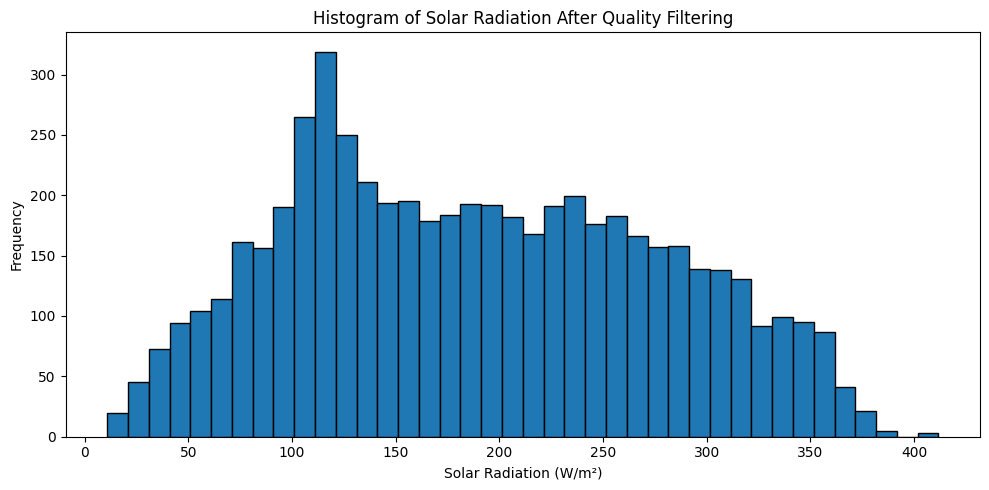

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(clean_df["solar_t"], bins=40, edgecolor="black")

plt.title("Histogram of Solar Radiation After Quality Filtering")
plt.xlabel("Solar Radiation (W/m²)")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(FIG_DIR / "partA_histogram_filtered.png", dpi=200)
plt.show()

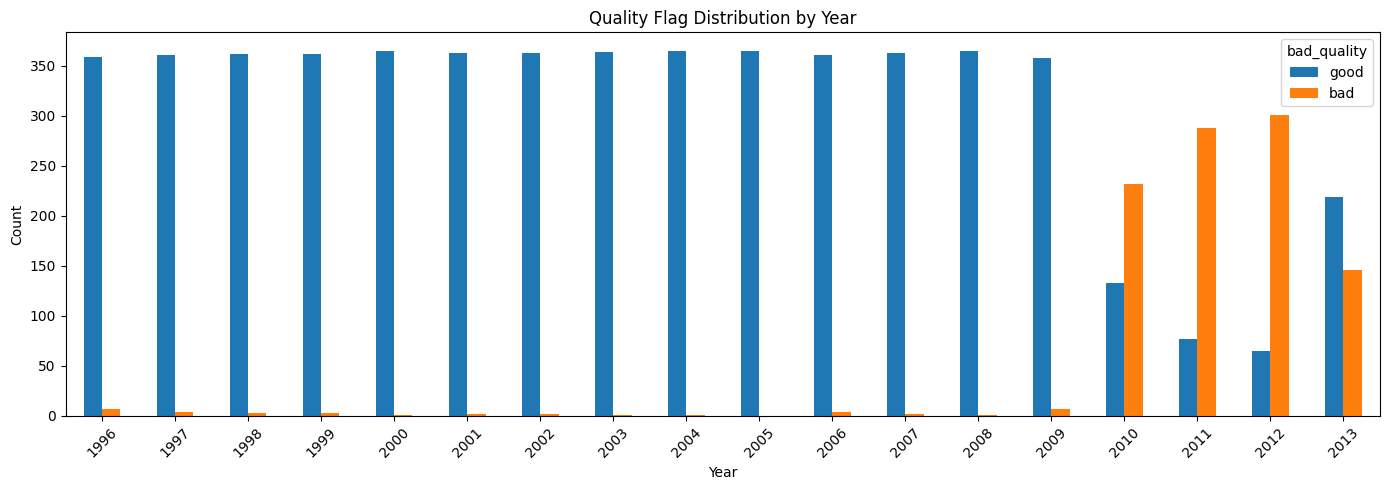

bad_quality,good,bad
year,,
1996,359,7
1997,361,4
1998,362,3
1999,362,3
2000,365,1


In [9]:
solar_df["year"] = solar_df["date"].dt.year

quality_summary = (
    solar_df.groupby(["year", "bad_quality"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: "good", 1: "bad"})
)

quality_summary.plot(kind="bar", figsize=(14, 5))

plt.title("Quality Flag Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(FIG_DIR / "partA_quality_by_year.png", dpi=200)
plt.show()

quality_summary.head()

In [10]:
partA_df = clean_df.copy()

partA_df["day_of_year"] = partA_df["date"].dt.dayofyear
partA_df["is_leap_year"] = partA_df["date"].dt.is_leap_year.astype(int)
partA_df["days_in_year"] = np.where(partA_df["is_leap_year"] == 1, 366, 365)

partA_df["day_sin"] = np.sin(2 * np.pi * partA_df["day_of_year"] / partA_df["days_in_year"])
partA_df["day_cos"] = np.cos(2 * np.pi * partA_df["day_of_year"] / partA_df["days_in_year"])

partA_df[["date", "day_of_year", "days_in_year", "day_sin", "day_cos"]].head()

,date,day_of_year,days_in_year,day_sin,day_cos
0,1996-01-01,1,366,0.017166,0.999853
1,1996-01-02,2,366,0.034328,0.999411
2,1996-01-03,3,366,0.051479,0.998674
3,1996-01-04,4,366,0.068615,0.997643
4,1996-01-05,5,366,0.085731,0.996318


In [11]:
partA_df["solar_mean_7d"] = partA_df["solar_t"].rolling(window=7, min_periods=7).mean()
partA_df["solar_std_7d"]  = partA_df["solar_t"].rolling(window=7, min_periods=7).std(ddof=1)
partA_df["solar_min_7d"]  = partA_df["solar_t"].rolling(window=7, min_periods=7).min()
partA_df["solar_max_7d"]  = partA_df["solar_t"].rolling(window=7, min_periods=7).max()

partA_df[[
    "date", "solar_t",
    "solar_mean_7d", "solar_std_7d", "solar_min_7d", "solar_max_7d"
]].head(10)

,date,solar_t,solar_mean_7d,solar_std_7d,solar_min_7d,solar_max_7d
0,1996-01-01,35.675000,NaN,NaN,NaN,NaN
1,1996-01-02,105.147917,NaN,NaN,NaN,NaN
2,1996-01-03,100.647917,NaN,NaN,NaN,NaN
3,1996-01-04,30.275000,NaN,NaN,NaN,NaN
4,1996-01-05,92.141962,NaN,NaN,NaN,NaN
5,1996-01-07,110.547917,NaN,NaN,NaN,NaN
6,1996-01-08,110.200000,83.519387,35.123533,30.275,110.547917
7,1996-01-09,68.202083,88.166114,29.428912,30.275,110.547917
8,1996-01-10,103.577083,87.941709,29.283468,30.275,110.547917
9,1996-01-11,93.595833,86.934268,28.892173,30.275,110.547917


In [12]:
for k in range(1, 8):
    partA_df[f"lag_{k}"] = partA_df["solar_t"].shift(k)

lag_cols = [f"lag_{k}" for k in range(1, 8)]

partA_df[["date", "solar_t"] + lag_cols].head(12)

,date,solar_t,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
0,1996-01-01,35.675000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1996-01-02,105.147917,35.675000,NaN,NaN,NaN,NaN,NaN,NaN
2,1996-01-03,100.647917,105.147917,35.675000,NaN,NaN,NaN,NaN,NaN
3,1996-01-04,30.275000,100.647917,105.147917,35.675000,NaN,NaN,NaN,NaN
4,1996-01-05,92.141962,30.275000,100.647917,105.147917,35.675000,NaN,NaN,NaN
5,1996-01-07,110.547917,92.141962,30.275000,100.647917,105.147917,35.675000,NaN,NaN
6,1996-01-08,110.200000,110.547917,92.141962,30.275000,100.647917,105.147917,35.675000,NaN
7,1996-01-09,68.202083,110.200000,110.547917,92.141962,30.275000,100.647917,105.147917,35.675000
8,1996-01-10,103.577083,68.202083,110.200000,110.547917,92.141962,30.275000,100.647917,105.147917
9,1996-01-11,93.595833,103.577083,68.202083,110.200000,110.547917,92.141962,30.275000,100.647917


In [13]:
for k in range(1, 8):
    partA_df[f"target_t_plus_{k}"] = partA_df["solar_t"].shift(-k)

target_cols = [f"target_t_plus_{k}" for k in range(1, 8)]

partA_df[["date", "solar_t"] + target_cols].tail(12)

,date,solar_t,target_t_plus_1,target_t_plus_2,target_t_plus_3,target_t_plus_4,target_t_plus_5,target_t_plus_6,target_t_plus_7
5558,2013-12-14,117.141516,115.559206,36.840652,68.584222,105.195489,99.495367,114.115032,114.599856
5559,2013-12-15,115.559206,36.840652,68.584222,105.195489,99.495367,114.115032,114.599856,64.218591
5560,2013-12-20,36.840652,68.584222,105.195489,99.495367,114.115032,114.599856,64.218591,117.232673
5561,2013-12-21,68.584222,105.195489,99.495367,114.115032,114.599856,64.218591,117.232673,128.697692
5562,2013-12-22,105.195489,99.495367,114.115032,114.599856,64.218591,117.232673,128.697692,123.242057
5563,2013-12-23,99.495367,114.115032,114.599856,64.218591,117.232673,128.697692,123.242057,NaN
5564,2013-12-25,114.115032,114.599856,64.218591,117.232673,128.697692,123.242057,NaN,NaN
5565,2013-12-27,114.599856,64.218591,117.232673,128.697692,123.242057,NaN,NaN,NaN
5566,2013-12-28,64.218591,117.232673,128.697692,123.242057,NaN,NaN,NaN,NaN
5567,2013-12-29,117.232673,128.697692,123.242057,NaN,NaN,NaN,NaN,NaN


In [14]:
feature_cols = [
    "day_sin",
    "day_cos",
    "solar_mean_7d",
    "solar_std_7d",
    "solar_min_7d",
    "solar_max_7d",
] + lag_cols

required_cols = feature_cols + target_cols

model_df = partA_df.dropna(subset=required_cols).copy().reset_index(drop=True)

print("partA_df shape:", partA_df.shape)
print("model_df shape:", model_df.shape)
model_df.head()

partA_df shape: (5570, 26)
model_df shape: (5556, 26)


,date,solar_t,bad_quality,day_of_year,is_leap_year,days_in_year,day_sin,day_cos,solar_mean_7d,solar_std_7d,...,lag_5,lag_6,lag_7,target_t_plus_1,target_t_plus_2,target_t_plus_3,target_t_plus_4,target_t_plus_5,target_t_plus_6,target_t_plus_7
0,1996-01-09,68.202083,0,9,1,366,0.153891,0.988088,88.166114,29.428912,...,100.647917,105.147917,35.675000,103.577083,93.595833,117.706250,119.747917,120.781250,114.291667,110.256250
1,1996-01-10,103.577083,0,10,1,366,0.170830,0.985301,87.941709,29.283468,...,30.275000,100.647917,105.147917,93.595833,117.706250,119.747917,120.781250,114.291667,110.256250,33.868750
2,1996-01-11,93.595833,0,11,1,366,0.187719,0.982223,86.934268,28.892173,...,92.141962,30.275000,100.647917,117.706250,119.747917,120.781250,114.291667,110.256250,33.868750,131.656250
3,1996-01-12,117.706250,0,12,1,366,0.204552,0.978856,99.424447,16.598977,...,110.547917,92.141962,30.275000,119.747917,120.781250,114.291667,110.256250,33.868750,131.656250,128.362500
4,1996-01-13,119.747917,0,13,1,366,0.221325,0.975200,103.368155,17.815233,...,110.200000,110.547917,92.141962,120.781250,114.291667,110.256250,33.868750,131.656250,128.362500,120.991667


In [15]:
trainval_df = model_df[model_df["date"].dt.year <= 2010].copy().reset_index(drop=True)
test_df = model_df[model_df["date"].dt.year >= 2011].copy().reset_index(drop=True)

val_ratio = 0.20
split_idx = int(len(trainval_df) * (1 - val_ratio))

train_df = trainval_df.iloc[:split_idx].copy().reset_index(drop=True)
val_df = trainval_df.iloc[split_idx:].copy().reset_index(drop=True)

print("Before dropping boundary rows:")
print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)

print("\nDate ranges:")
print("Train:", train_df["date"].min(), "to", train_df["date"].max())
print("Val:  ", val_df["date"].min(), "to", val_df["date"].max())
print("Test: ", test_df["date"].min(), "to", test_df["date"].max())

Before dropping boundary rows:
Train: (4161, 26)
Val:   (1041, 26)
Test:  (354, 26)

Date ranges:
Train: 1996-01-09 00:00:00 to 2007-06-28 00:00:00
Val:   2007-06-29 00:00:00 to 2010-12-31 00:00:00
Test:  2011-01-01 00:00:00 to 2013-12-22 00:00:00


In [16]:
val_df = val_df.iloc[7:].copy().reset_index(drop=True)
test_df = test_df.iloc[7:].copy().reset_index(drop=True)

print("After dropping boundary rows:")
print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)

After dropping boundary rows:
Train: (4161, 26)
Val:   (1034, 26)
Test:  (347, 26)


In [17]:
X_train = train_df[feature_cols].copy()
X_val   = val_df[feature_cols].copy()
X_test  = test_df[feature_cols].copy()

y_train = train_df[target_cols].copy()
y_val   = val_df[target_cols].copy()
y_test  = test_df[target_cols].copy()

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

X_train: (4161, 13)
X_val:   (1034, 13)
X_test:  (347, 13)
y_train: (4161, 7)
y_val:   (1034, 7)
y_test:  (347, 7)


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, SCALER_DIR / "feature_scaler.pkl")

print("Scaler saved.")
print(X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)

Scaler saved.
(4161, 13) (1034, 13) (347, 13)


In [19]:
np.save(OUTPUT_DIR / "X_train.npy", X_train_scaled)
np.save(OUTPUT_DIR / "X_val.npy", X_val_scaled)
np.save(OUTPUT_DIR / "X_test.npy", X_test_scaled)

np.save(OUTPUT_DIR / "y_train.npy", y_train.values)
np.save(OUTPUT_DIR / "y_val.npy", y_val.values)
np.save(OUTPUT_DIR / "y_test.npy", y_test.values)

train_df.to_csv(OUTPUT_DIR / "train_processed.csv", index=False)
val_df.to_csv(OUTPUT_DIR / "val_processed.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "test_processed.csv", index=False)

print("Processed files saved.")

Processed files saved.


In [20]:
partA_summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "rows": [len(train_df), len(val_df), len(test_df)],
    "start_date": [train_df["date"].min(), val_df["date"].min(), test_df["date"].min()],
    "end_date": [train_df["date"].max(), val_df["date"].max(), test_df["date"].max()]
})

partA_summary

,split,rows,start_date,end_date
0,train,4161,1996-01-09,2007-06-28
1,val,1034,2007-07-06,2010-12-31
2,test,347,2011-01-26,2013-12-22


## Part B — Multi-Output Model with Custom Loss Function

- Feedforward neural network built. 
- Loss function comparison done using: 
    - Weighted MSE (baseline)
    - Pseudo-Huber Loss (smooth robust alternative)
    - Weighted Quantile Liss (asymmetric pinball loss)
- 3 models trained with atleast 15 epochs
- Evaluation - see evaluation cell

In [21]:
SEED = 42

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import mean_squared_error, mean_absolute_error

tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [22]:
input_dim = X_train_scaled.shape[1]

def build_model():
    
    model = keras.Sequential([
        
        layers.Input(shape=(input_dim,)),
        
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        
        layers.Dense(7, activation="linear")
        
    ])
    
    return model

In [23]:
horizon_weights = tf.constant(
    [1 / np.sqrt(k) for k in range(1, 8)],
    dtype=tf.float32
)

def weighted_mse(y_true, y_pred):
    
    error = tf.square(y_true - y_pred)
    
    weighted_error = error * horizon_weights
    
    return tf.reduce_mean(weighted_error)

In [24]:
model_mse = build_model()

model_mse.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=weighted_mse
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history_mse = model_mse.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


E0000 00:00:1773730926.465146 8935904 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 20646.0430 - val_loss: 9070.9883
Epoch 2/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 761us/step - loss: 5528.6841 - val_loss: 4265.4185
Epoch 3/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 738us/step - loss: 3608.1030 - val_loss: 3060.6445
Epoch 4/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 591us/step - loss: 2667.0674 - val_loss: 2321.2537
Epoch 5/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 550us/step - loss: 2222.1279 - val_loss: 2047.0059
Epoch 6/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 556us/step - loss: 2077.9446 - val_loss: 1960.6300
Epoch 7/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step - loss: 2026.8873 - val_loss: 1923.1937
Epoch 8/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 564us/step - loss: 1999.3895 - val_loss: 1901.1411
Epoch 9/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step - loss: 1981.9182 - val_loss: 1887.1307
Epoch 10/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step - loss: 1969.5353 - val_loss: 1877.2117
Epoch 11/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 519us/step - loss

In [25]:
y_pred = model_mse.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
RMSE: 61.76760526802763
MAE: 48.04092025756836


In [26]:
def compute_metrics_per_horizon(y_true, y_pred):
    results = []

    for i in range(7):
        yt = y_true.iloc[:, i].values if hasattr(y_true, "iloc") else y_true[:, i]
        yp = y_pred[:, i]

        rmse = np.sqrt(mean_squared_error(yt, yp))
        mae = mean_absolute_error(yt, yp)
        mbe = np.mean(yp - yt)
        p95 = np.percentile(np.abs(yp - yt), 95)

        results.append({
            "horizon": f"t+{i+1}",
            "RMSE": rmse,
            "MAE": mae,
            "MBE": mbe,
            "P95": p95
        })

    df_results = pd.DataFrame(results)

    macro_row = pd.DataFrame([{
        "horizon": "macro_avg",
        "RMSE": df_results["RMSE"].mean(),
        "MAE": df_results["MAE"].mean(),
        "MBE": df_results["MBE"].mean(),
        "P95": df_results["P95"].mean()
    }])

    return pd.concat([df_results, macro_row], ignore_index=True)

In [27]:
def train_and_evaluate_model(loss_fn, model_name):
    model = build_model()

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=loss_fn
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        verbose=1
    )

    y_pred = model.predict(X_test_scaled, verbose=0)
    metrics_df = compute_metrics_per_horizon(y_test, y_pred)

    return model, history, y_pred, metrics_df

In [28]:
def pseudo_huber_loss(delta=50.0):
    def loss(y_true, y_pred):
        error = y_true - y_pred
        return tf.reduce_mean(
            delta**2 * (tf.sqrt(1.0 + tf.square(error / delta)) - 1.0)
        )
    return loss

In [29]:
model_huber, history_huber, y_pred_huber, metrics_huber = train_and_evaluate_model(
    pseudo_huber_loss(delta=50.0),
    "pseudo_huber"
)

metrics_huber

Epoch 1/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 6228.4131 - val_loss: 3135.5989
Epoch 2/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 541us/step - loss: 2462.8467 - val_loss: 2165.4446
Epoch 3/100
  1/131 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1617.6034

E0000 00:00:1773730931.783473 8935904 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 625us/step - loss: 1887.5900 - val_loss: 1655.7424
Epoch 4/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 539us/step - loss: 1428.2859 - val_loss: 1243.6951
Epoch 5/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step - loss: 1175.3986 - val_loss: 1095.7406
Epoch 6/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step - loss: 1109.3999 - val_loss: 1061.7664
Epoch 7/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 552us/step - loss: 1091.9628 - val_loss: 1047.6445
Epoch 8/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 526us/step - loss: 1082.7332 - val_loss: 1038.9459
Epoch 9/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 522us/step - loss: 1076.1597 - val_loss: 1033.0829
Epoch 10/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 630us/step - loss: 1071.5171 - val_loss: 1028.9950
Epoch 11/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 551us/step - loss: 1067.9579 - val_loss: 1026.1052
Epoch 12/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 518us/step - loss: 1065.2555 - val_loss: 1023.9662
Epoch 13/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 532us/step - l

E0000 00:00:1773730938.704779 8935904 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,horizon,RMSE,MAE,MBE,P95
0,t+1,58.391023,44.902657,2.761525,119.708567
1,t+2,59.180939,45.712784,0.688139,129.069189
2,t+3,60.130944,46.342598,3.019445,133.054083
3,t+4,60.712367,46.940284,0.888580,138.562599
4,t+5,62.080979,47.629188,2.341471,142.605933
5,t+6,63.679403,48.549239,2.414588,141.568460
6,t+7,64.633153,49.703477,0.180588,142.345763
7,macro_avg,61.258401,47.111461,1.756334,135.273513


In [30]:
def weighted_quantile_loss(q=0.8):
    def loss(y_true, y_pred):
        error = y_true - y_pred
        quantile_part = tf.maximum(q * error, (q - 1.0) * error)
        weighted = quantile_part * horizon_weights
        return tf.reduce_mean(weighted)
    return loss

In [31]:
model_quantile, history_quantile, y_pred_quantile, metrics_quantile = train_and_evaluate_model(
    weighted_quantile_loss(q=0.8),
    "weighted_quantile"
)

metrics_quantile

Epoch 1/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 998us/step - loss: 77.0193 - val_loss: 47.2618
Epoch 2/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step - loss: 27.2249 - val_loss: 20.3823
Epoch 3/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 609us/step - loss: 17.6557 - val_loss: 15.5962
Epoch 4/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 537us/step - loss: 12.7909 - val_loss: 10.8695
Epoch 5/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step - loss: 9.1482 - val_loss: 8.0633
Epoch 6/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step - loss: 7.6206 - val_loss: 7.3151
Epoch 7/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 549us/step - loss: 7.2566 - val_loss: 7.0942
Epoch 8/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 579us/step - loss: 7.0981 - val_loss: 6.9802
Epoch 9/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 539us/step - loss: 6.9964 - val_loss: 6.9087
Epoch 10/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 526us/step - loss: 6.9301 - val_loss: 6.8702
Epoch 11/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 562us/step - loss: 6.8859 - val_loss: 6.8478
Epoch 12/10

E0000 00:00:1773730946.745277 8935904 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,horizon,RMSE,MAE,MBE,P95
0,t+1,74.064574,52.189794,43.957570,160.707250
1,t+2,75.055628,53.553353,44.219093,176.741835
2,t+3,74.614060,53.491014,42.338862,172.527089
3,t+4,76.955791,55.528305,44.499647,177.305323
4,t+5,77.908574,56.426051,43.395740,179.369795
5,t+6,79.575128,57.347865,44.329907,179.020119
6,t+7,79.568288,57.225399,41.828575,173.266507
7,macro_avg,76.820292,55.108826,43.509913,174.133988


In [32]:
model_mse, history_mse, y_pred_mse, metrics_mse = train_and_evaluate_model(
    weighted_mse,
    "weighted_mse"
)

metrics_mse

Epoch 1/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 978us/step - loss: 20456.4180 - val_loss: 8469.5176
Epoch 2/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step - loss: 5669.3535 - val_loss: 4696.2358
Epoch 3/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 526us/step - loss: 4052.4539 - val_loss: 3546.7227
Epoch 4/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 522us/step - loss: 3004.6738 - val_loss: 2569.5325
Epoch 5/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 524us/step - loss: 2341.5737 - val_loss: 2107.5486
Epoch 6/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 523us/step - loss: 2098.3250 - val_loss: 1966.6862
Epoch 7/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 517us/step - loss: 2025.7661 - val_loss: 1919.2694
Epoch 8/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 521us/step - loss: 1995.8827 - val_loss: 1897.2954
Epoch 9/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 519us/step - loss: 1978.1123 - val_loss: 1883.9662
Epoch 10/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 521us/step - loss: 1965.7318 - val_loss: 1875.1567
Epoch 11/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 519

,horizon,RMSE,MAE,MBE,P95
0,t+1,58.051034,45.466052,-3.203991,127.762844
1,t+2,59.319964,46.362272,-4.685232,126.427866
2,t+3,60.330482,47.137261,-2.520071,135.481291
3,t+4,61.271335,47.935881,-3.759416,136.167011
4,t+5,62.734361,48.559518,-3.499104,138.747097
5,t+6,64.523911,49.989134,-3.863194,139.334577
6,t+7,65.646323,51.197015,-5.393684,146.098359
7,macro_avg,61.696773,48.092448,-3.846385,135.717007


In [33]:
summary_partB = pd.DataFrame([
    {
        "loss": "Weighted MSE",
        "RMSE": metrics_mse.loc[metrics_mse["horizon"] == "macro_avg", "RMSE"].values[0],
        "MAE": metrics_mse.loc[metrics_mse["horizon"] == "macro_avg", "MAE"].values[0],
        "MBE": metrics_mse.loc[metrics_mse["horizon"] == "macro_avg", "MBE"].values[0],
        "P95": metrics_mse.loc[metrics_mse["horizon"] == "macro_avg", "P95"].values[0]
    },
    {
        "loss": "Pseudo-Huber",
        "RMSE": metrics_huber.loc[metrics_huber["horizon"] == "macro_avg", "RMSE"].values[0],
        "MAE": metrics_huber.loc[metrics_huber["horizon"] == "macro_avg", "MAE"].values[0],
        "MBE": metrics_huber.loc[metrics_huber["horizon"] == "macro_avg", "MBE"].values[0],
        "P95": metrics_huber.loc[metrics_huber["horizon"] == "macro_avg", "P95"].values[0]
    },
    {
        "loss": "Weighted Quantile",
        "RMSE": metrics_quantile.loc[metrics_quantile["horizon"] == "macro_avg", "RMSE"].values[0],
        "MAE": metrics_quantile.loc[metrics_quantile["horizon"] == "macro_avg", "MAE"].values[0],
        "MBE": metrics_quantile.loc[metrics_quantile["horizon"] == "macro_avg", "MBE"].values[0],
        "P95": metrics_quantile.loc[metrics_quantile["horizon"] == "macro_avg", "P95"].values[0]
    }
])

summary_partB

,loss,RMSE,MAE,MBE,P95
0,Weighted MSE,61.696773,48.092448,-3.846385,135.717007
1,Pseudo-Huber,61.258401,47.111461,1.756334,135.273513
2,Weighted Quantile,76.820292,55.108826,43.509913,174.133988


In [34]:
def plot_training_history(history, title):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

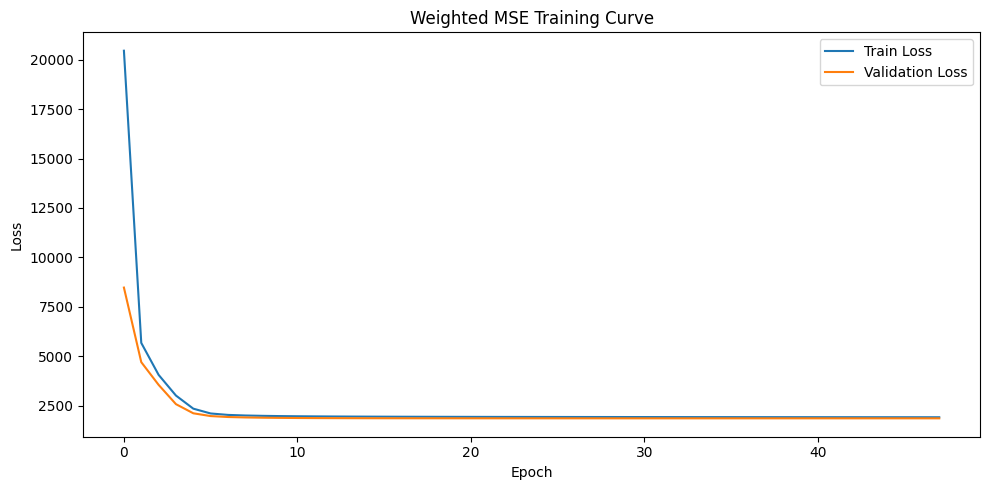

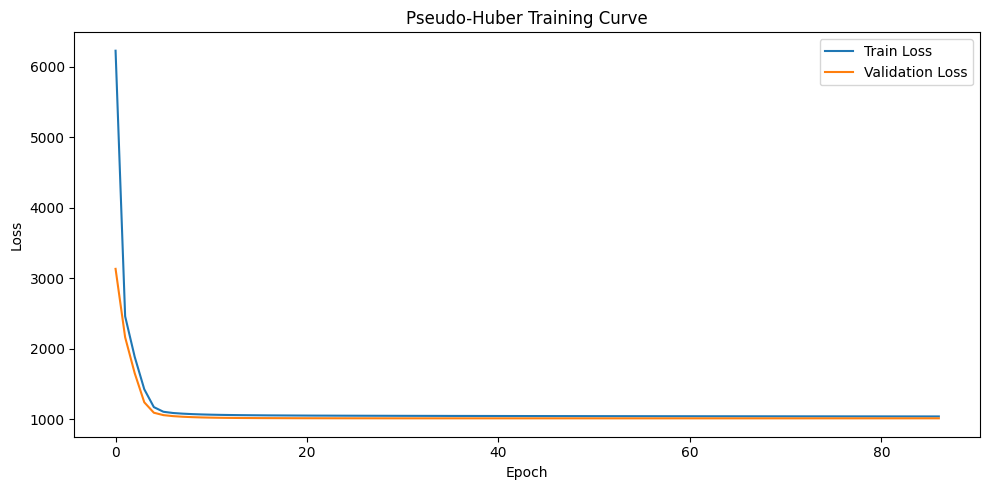

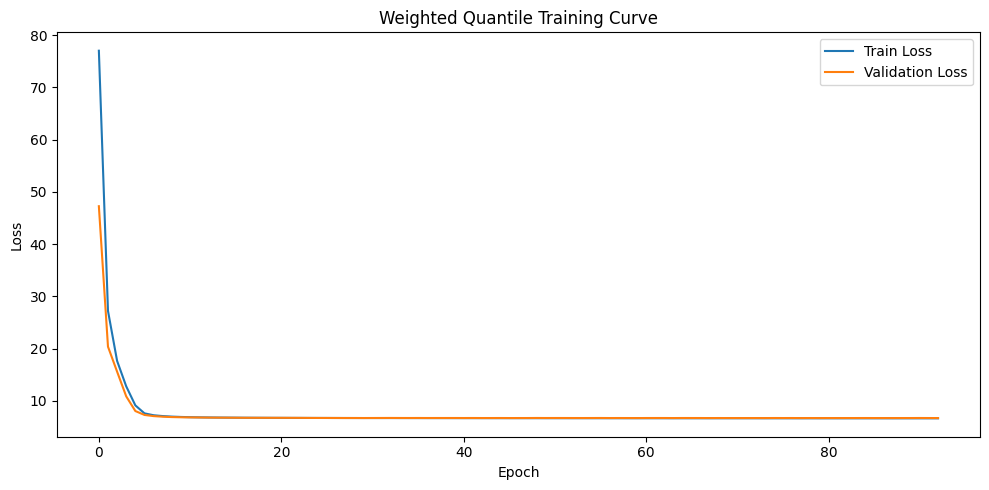

In [35]:
plot_training_history(history_mse, "Weighted MSE Training Curve")
plot_training_history(history_huber, "Pseudo-Huber Training Curve")
plot_training_history(history_quantile, "Weighted Quantile Training Curve")

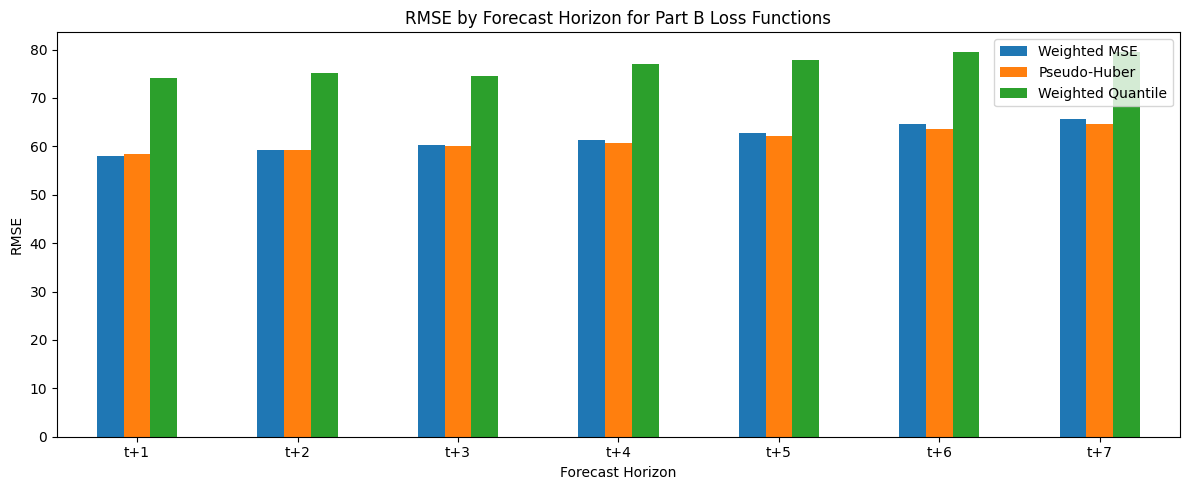

In [36]:
rmse_compare = pd.DataFrame({
    "horizon": metrics_mse.loc[metrics_mse["horizon"] != "macro_avg", "horizon"].values,
    "Weighted MSE": metrics_mse.loc[metrics_mse["horizon"] != "macro_avg", "RMSE"].values,
    "Pseudo-Huber": metrics_huber.loc[metrics_huber["horizon"] != "macro_avg", "RMSE"].values,
    "Weighted Quantile": metrics_quantile.loc[metrics_quantile["horizon"] != "macro_avg", "RMSE"].values
})

rmse_compare.plot(x="horizon", kind="bar", figsize=(12, 5))
plt.title("RMSE by Forecast Horizon for Part B Loss Functions")
plt.ylabel("RMSE")
plt.xlabel("Forecast Horizon")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [37]:
def plot_metric_comparison(metric_name):
    compare_df = pd.DataFrame({
        "horizon": metrics_mse.loc[metrics_mse["horizon"] != "macro_avg", "horizon"].values,
        "Weighted MSE": metrics_mse.loc[metrics_mse["horizon"] != "macro_avg", metric_name].values,
        "Pseudo-Huber": metrics_huber.loc[metrics_huber["horizon"] != "macro_avg", metric_name].values,
        "Weighted Quantile": metrics_quantile.loc[metrics_quantile["horizon"] != "macro_avg", metric_name].values
    })

    compare_df.plot(x="horizon", kind="bar", figsize=(12, 5))
    plt.title(f"{metric_name} by Forecast Horizon for Part B Loss Functions")
    plt.ylabel(metric_name)
    plt.xlabel("Forecast Horizon")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

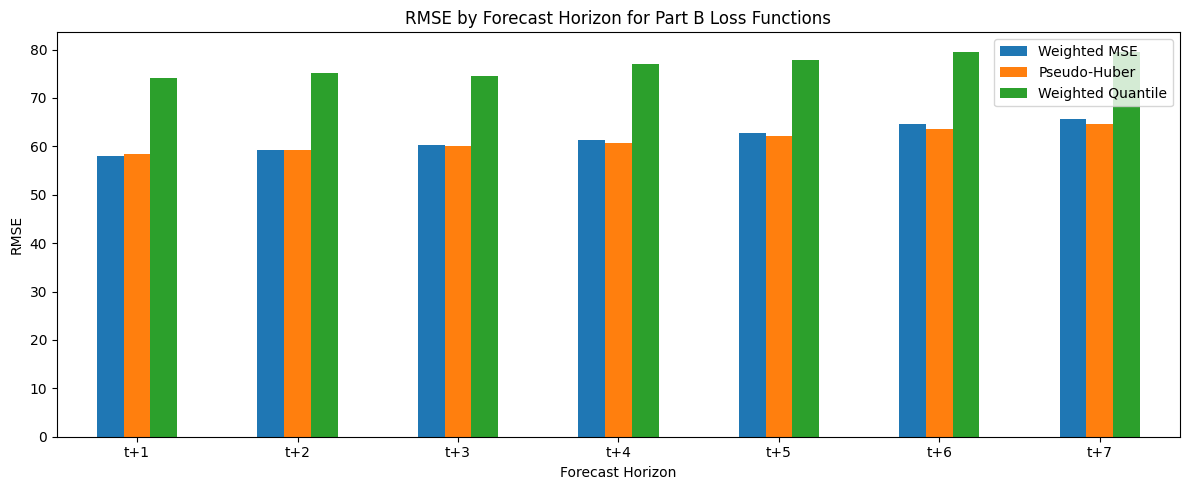

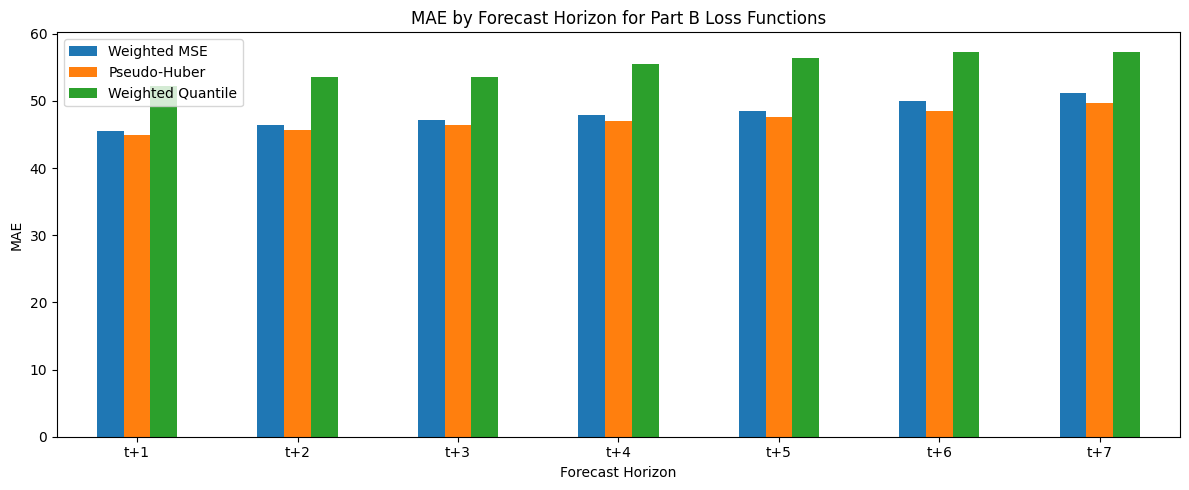

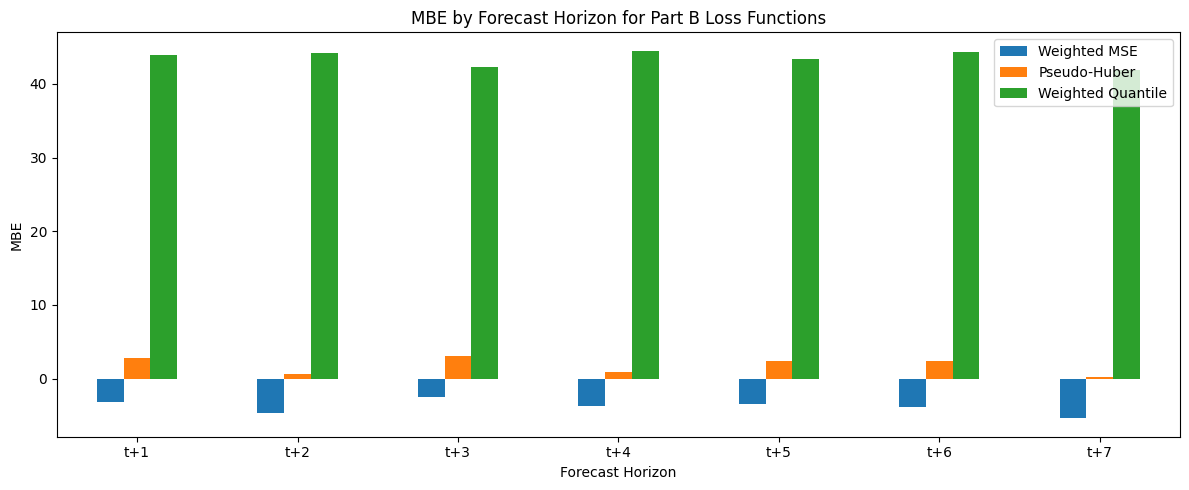

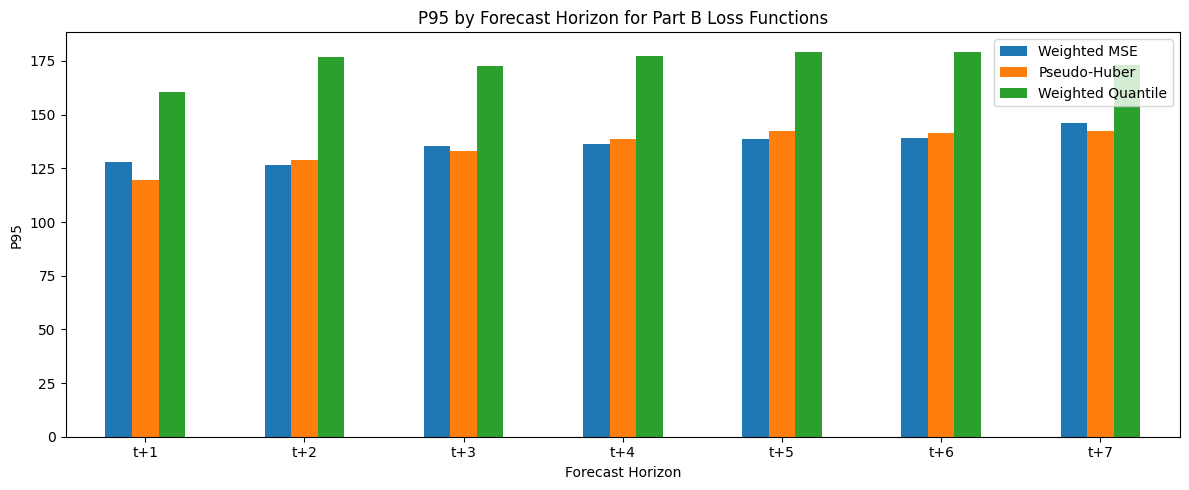

In [38]:
plot_metric_comparison("RMSE")
plot_metric_comparison("MAE")
plot_metric_comparison("MBE")
plot_metric_comparison("P95")

## Part C — Individual Models and Transfer Learning

- Individual Model Development:
    - Seven Seperate Models
    - Transfer Learning Strategies:
        - Sequential Fine-tuning
        - Feature Extraction
        - Multi-task learning
    - Comparison

In [39]:
y_train_np = y_train.values
y_val_np = y_val.values
y_test_np = y_test.values

print("y_train_np:", y_train_np.shape)
print("y_val_np:  ", y_val_np.shape)
print("y_test_np: ", y_test_np.shape)

y_train_np: (4161, 7)
y_val_np:   (1034, 7)
y_test_np:  (347, 7)


In [40]:
import time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [41]:
def build_single_output_model():
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [42]:
independent_results = []
independent_models = []

for horizon in range(7):

    print(f"\nTraining model for horizon t+{horizon+1}")

    y_train_h = y_train_np[:, horizon]
    y_val_h = y_val_np[:, horizon]
    y_test_h = y_test_np[:, horizon]

    model = build_single_output_model()

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    start = time.time()

    model.fit(
        X_train_scaled,
        y_train_h,
        validation_data=(X_val_scaled, y_val_h),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    train_time = time.time() - start

    y_pred = model.predict(X_test_scaled, verbose=0).flatten()

    rmse = np.sqrt(mean_squared_error(y_test_h, y_pred))
    mae = mean_absolute_error(y_test_h, y_pred)

    independent_results.append({
        "horizon": f"t+{horizon+1}",
        "RMSE": rmse,
        "MAE": mae,
        "train_time": train_time
    })

    independent_models.append(model)

independent_df = pd.DataFrame(independent_results)
independent_df


Training model for horizon t+1


E0000 00:00:1773730952.038341 8935904 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1773730957.583881 8935904 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),


Training model for horizon t+2

Training model for horizon t+3


E0000 00:00:1773730965.166819 8935904 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Training model for horizon t+4


...


Training model for horizon t+5


E0000 00:00:1773730979.020423 8935904 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Training model for horizon t+6

Training model for horizon t+7


E0000 00:00:1773730988.674749 8935904 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,horizon,RMSE,MAE,train_time
0,t+1,58.216123,45.047517,6.092682
1,t+2,60.573057,47.166373,3.113624
2,t+3,61.498889,48.096041,4.348291
3,t+4,61.723290,48.623093,7.968663
4,t+5,62.062543,47.928613,5.765907
5,t+6,63.729372,49.286765,4.310602
6,t+7,65.219415,50.638774,5.223558


In [43]:
seq_results = []
previous_model = None

for horizon in range(7):

    print(f"\nSequential training horizon t+{horizon+1}")

    y_train_h = y_train_np[:, horizon]
    y_val_h = y_val_np[:, horizon]
    y_test_h = y_test_np[:, horizon]

    if previous_model is None:
        model = build_single_output_model()
    else:
        model = build_single_output_model()
        model.set_weights(previous_model.get_weights())

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    start = time.time()

    model.fit(
        X_train_scaled,
        y_train_h,
        validation_data=(X_val_scaled, y_val_h),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    train_time = time.time() - start

    y_pred = model.predict(X_test_scaled, verbose=0).flatten()

    rmse = np.sqrt(mean_squared_error(y_test_h, y_pred))
    mae = mean_absolute_error(y_test_h, y_pred)

    seq_results.append({
        "horizon": f"t+{horizon+1}",
        "RMSE": rmse,
        "MAE": mae,
        "train_time": train_time
    })

    previous_model = model

seq_df = pd.DataFrame(seq_results)
seq_df


Sequential training horizon t+1


E0000 00:00:1773730996.211754 8935904 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Sequential training horizon t+2


E0000 00:00:1773731001.270003 8935904 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Sequential training horizon t+3


E0000 00:00:1773731007.072220 8935904 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Sequential training horizon t+4

Sequential training horizon t+5


E0000 00:00:1773731012.350291 8935904 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Sequential training horizon t+6

Sequential training horizon t+7


,horizon,RMSE,MAE,train_time
0,t+1,58.125331,45.026374,7.468767
1,t+2,60.148758,46.852421,4.997474
2,t+3,61.630804,47.811798,5.741494
3,t+4,61.656196,48.336681,3.129700
4,t+5,61.627967,47.635529,2.017490
5,t+6,63.360041,48.825964,2.415005
6,t+7,65.064068,50.453425,1.903560


In [44]:
def build_single_output_model_functional():
    inputs = keras.Input(shape=(input_dim,), name="input_layer")
    x = layers.Dense(64, activation="relu", name="dense_1")(inputs)
    x = layers.Dense(64, activation="relu", name="dense_2")(x)
    outputs = layers.Dense(1, name="output_layer")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [45]:
base_model = build_single_output_model_functional()

base_model.fit(
    X_train_scaled,
    y_train_np[:, 0],
    validation_data=(X_val_scaled, y_val_np[:, 0]),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)],
    verbose=0
)

E0000 00:00:1773731017.402459 8935904 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


In [46]:
inputs = keras.Input(shape=(input_dim,), name="input_layer")

x = layers.Dense(64, activation="relu", name="dense_1")(inputs)
x = layers.Dense(64, activation="relu", name="dense_2")(x)
outputs = layers.Dense(1, name="new_output_layer")(x)

feature_model = keras.Model(inputs=inputs, outputs=outputs)

In [47]:
feature_model.get_layer("dense_1").set_weights(
    base_model.get_layer("dense_1").get_weights()
)
feature_model.get_layer("dense_2").set_weights(
    base_model.get_layer("dense_2").get_weights()
)

In [48]:
feature_model.get_layer("dense_1").trainable = False
feature_model.get_layer("dense_2").trainable = False

In [49]:
start = time.time()

feature_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

feature_model.fit(
    X_train_scaled,
    y_train_np[:, 6],
    validation_data=(X_val_scaled, y_val_np[:, 6]),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)],
    verbose=0
)

feature_time = time.time() - start

E0000 00:00:1773731023.043730 8935904 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


In [50]:
y_pred_feature = feature_model.predict(X_test_scaled, verbose=0).flatten()

rmse_feature = np.sqrt(mean_squared_error(y_test_np[:, 6], y_pred_feature))
mae_feature = mean_absolute_error(y_test_np[:, 6], y_pred_feature)

feature_df = pd.DataFrame([{
    "horizon": "t+7",
    "RMSE": rmse_feature,
    "MAE": mae_feature,
    "train_time": feature_time
}])

feature_df

E0000 00:00:1773731030.281041 8935904 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,horizon,RMSE,MAE,train_time
0,t+7,68.565432,52.851106,7.235348


In [51]:
def build_multitask_model():
    inputs = keras.Input(shape=(input_dim,))

    shared = layers.Dense(64, activation="relu")(inputs)
    shared = layers.Dense(64, activation="relu")(shared)

    outputs = []
    for i in range(7):
        head = layers.Dense(32, activation="relu", name=f"head_hidden_{i+1}")(shared)
        out = layers.Dense(1, name=f"h{i+1}")(head)
        outputs.append(out)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [52]:
multitask_model = build_multitask_model()

start = time.time()

multitask_model.fit(
    X_train_scaled,
    [y_train_np[:, i] for i in range(7)],
    validation_data=(X_val_scaled, [y_val_np[:, i] for i in range(7)]),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)],
    verbose=0
)

multitask_time = time.time() - start

In [53]:
preds = multitask_model.predict(X_test_scaled, verbose=0)

multitask_results = []

for i in range(7):
    rmse = np.sqrt(mean_squared_error(y_test_np[:, i], preds[i].flatten()))
    mae = mean_absolute_error(y_test_np[:, i], preds[i].flatten())

    multitask_results.append({
        "horizon": f"t+{i+1}",
        "RMSE": rmse,
        "MAE": mae
    })

multitask_df = pd.DataFrame(multitask_results)
multitask_df

E0000 00:00:1773731037.957750 8935904 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,horizon,RMSE,MAE
0,t+1,58.997687,46.721840
1,t+2,59.903039,46.965418
2,t+3,60.667777,47.656661
3,t+4,61.797916,48.608455
4,t+5,63.510054,49.366978
5,t+6,64.993466,50.339069
6,t+7,65.701791,51.150186


In [54]:
partB_baseline_df = metrics_mse[metrics_mse["horizon"] != "macro_avg"][["horizon", "RMSE", "MAE"]].copy()
partB_baseline_df["train_time"] = np.nan
partB_baseline_df

,horizon,RMSE,MAE,train_time
0,t+1,58.051034,45.466052,NaN
1,t+2,59.319964,46.362272,NaN
2,t+3,60.330482,47.137261,NaN
3,t+4,61.271335,47.935881,NaN
4,t+5,62.734361,48.559518,NaN
5,t+6,64.523911,49.989134,NaN
6,t+7,65.646323,51.197015,NaN


In [55]:
comparison_df = pd.DataFrame({
    "horizon": independent_df["horizon"],
    "Part B Multi-output RMSE": partB_baseline_df["RMSE"].values,
    "Independent RMSE": independent_df["RMSE"].values,
    "Sequential TL RMSE": seq_df["RMSE"].values,
    "Multitask RMSE": multitask_df["RMSE"].values,
    "Part B Multi-output MAE": partB_baseline_df["MAE"].values,
    "Independent MAE": independent_df["MAE"].values,
    "Sequential TL MAE": seq_df["MAE"].values,
    "Multitask MAE": multitask_df["MAE"].values,
    "Independent train_time": independent_df["train_time"].values,
    "Sequential TL train_time": seq_df["train_time"].values,
})

comparison_df

,horizon,Part B Multi-output RMSE,Independent RMSE,Sequential TL RMSE,Multitask RMSE,Part B Multi-output MAE,Independent MAE,Sequential TL MAE,Multitask MAE,Independent train_time,Sequential TL train_time
0,t+1,58.051034,58.216123,58.125331,58.997687,45.466052,45.047517,45.026374,46.721840,6.092682,7.468767
1,t+2,59.319964,60.573057,60.148758,59.903039,46.362272,47.166373,46.852421,46.965418,3.113624,4.997474
2,t+3,60.330482,61.498889,61.630804,60.667777,47.137261,48.096041,47.811798,47.656661,4.348291,5.741494
3,t+4,61.271335,61.723290,61.656196,61.797916,47.935881,48.623093,48.336681,48.608455,7.968663,3.129700
4,t+5,62.734361,62.062543,61.627967,63.510054,48.559518,47.928613,47.635529,49.366978,5.765907,2.017490
5,t+6,64.523911,63.729372,63.360041,64.993466,49.989134,49.286765,48.825964,50.339069,4.310602,2.415005
6,t+7,65.646323,65.219415,65.064068,65.701791,51.197015,50.638774,50.453425,51.150186,5.223558,1.903560


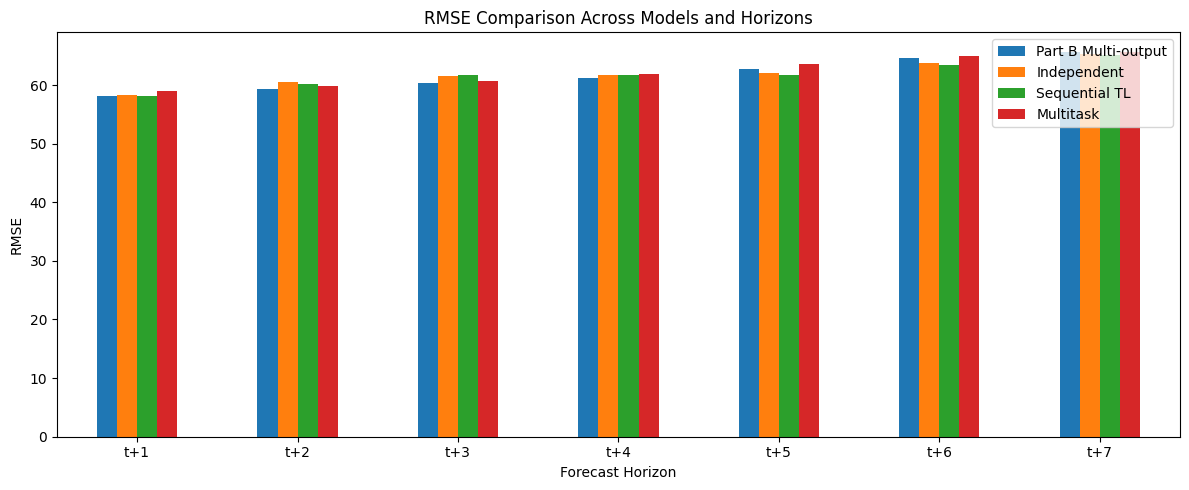

In [56]:
rmse_plot_df = pd.DataFrame({
    "horizon": independent_df["horizon"],
    "Part B Multi-output": partB_baseline_df["RMSE"].values,
    "Independent": independent_df["RMSE"].values,
    "Sequential TL": seq_df["RMSE"].values,
    "Multitask": multitask_df["RMSE"].values
})

rmse_plot_df.plot(x="horizon", kind="bar", figsize=(12, 5))
plt.title("RMSE Comparison Across Models and Horizons")
plt.ylabel("RMSE")
plt.xlabel("Forecast Horizon")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

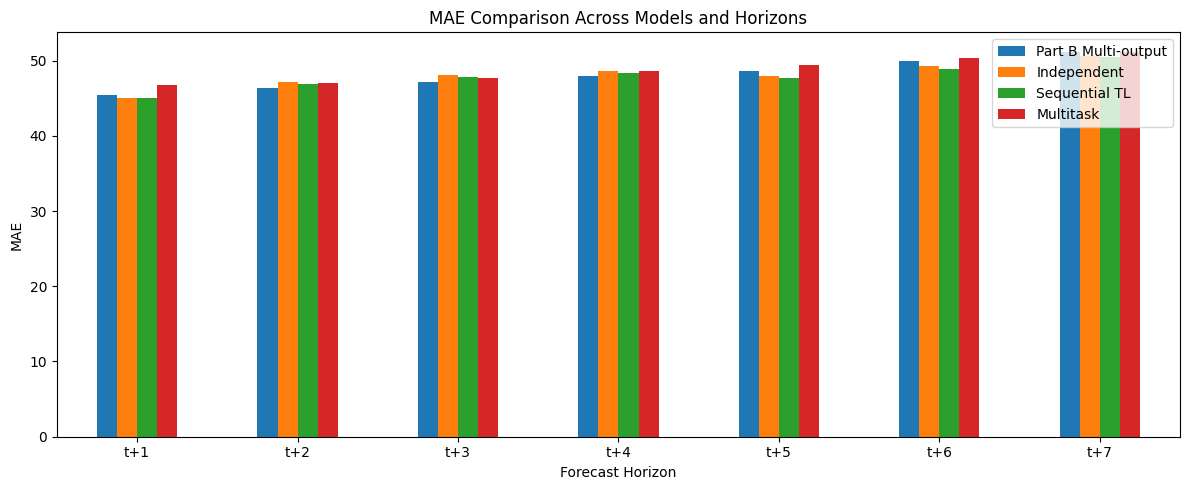

In [57]:
mae_plot_df = pd.DataFrame({
    "horizon": independent_df["horizon"],
    "Part B Multi-output": partB_baseline_df["MAE"].values,
    "Independent": independent_df["MAE"].values,
    "Sequential TL": seq_df["MAE"].values,
    "Multitask": multitask_df["MAE"].values
})

mae_plot_df.plot(x="horizon", kind="bar", figsize=(12, 5))
plt.title("MAE Comparison Across Models and Horizons")
plt.ylabel("MAE")
plt.xlabel("Forecast Horizon")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [58]:
feature_df

,horizon,RMSE,MAE,train_time
0,t+7,68.565432,52.851106,7.235348


In [59]:
feature_model.save(MODEL_DIR / "feature_extraction_t7_model.keras")

## Part D — Advanced Techniques

### 14. Uncertainty Quantification via Monte Carlo Dropout


In [60]:
def build_mc_dropout_model():

    inputs = keras.Input(shape=(input_dim,))

    x = layers.Dense(64, activation="relu")(inputs)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(7)(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [61]:
mc_model = build_mc_dropout_model()

mc_model.fit(
    X_train_scaled,
    y_train_np,
    validation_data=(X_val_scaled, y_val_np),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
    verbose=0
)

In [62]:
T = 50
mc_preds = []

for t in range(T):
    preds = mc_model(X_test_scaled, training=True).numpy()
    mc_preds.append(preds)

mc_preds = np.array(mc_preds)

In [63]:
mc_mean = mc_preds.mean(axis=0)
mc_var = mc_preds.var(axis=0)
mc_std = np.sqrt(mc_var)

In [64]:
mc_results = []

for i in range(7):

    rmse = np.sqrt(mean_squared_error(y_test_np[:,i], mc_mean[:,i]))
    mae = mean_absolute_error(y_test_np[:,i], mc_mean[:,i])

    mc_results.append({
        "horizon": f"t+{i+1}",
        "RMSE": rmse,
        "MAE": mae
    })

mc_df = pd.DataFrame(mc_results)
mc_df

,horizon,RMSE,MAE
0,t+1,58.356344,45.659521
1,t+2,58.893817,46.125510
2,t+3,60.328959,47.423894
3,t+4,61.195142,47.876667
4,t+5,62.646186,48.740285
5,t+6,63.984257,49.667448
6,t+7,65.172708,50.958564


In [65]:
mc_macro = pd.DataFrame([{
    "horizon": "macro_avg",
    "RMSE": mc_df["RMSE"].mean(),
    "MAE": mc_df["MAE"].mean()
}])

mc_df = pd.concat([mc_df, mc_macro], ignore_index=True)
mc_df

,horizon,RMSE,MAE
0,t+1,58.356344,45.659521
1,t+2,58.893817,46.125510
2,t+3,60.328959,47.423894
3,t+4,61.195142,47.876667
4,t+5,62.646186,48.740285
5,t+6,63.984257,49.667448
6,t+7,65.172708,50.958564
7,macro_avg,61.511059,48.064556


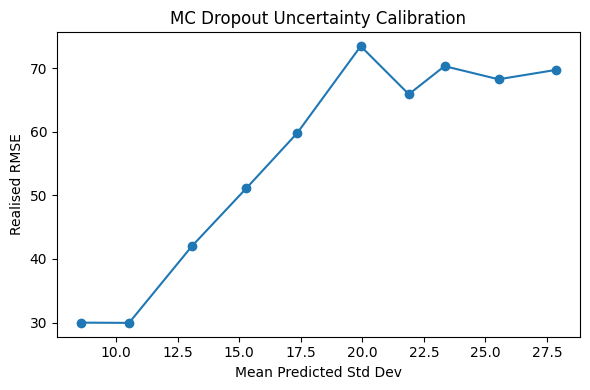

In [66]:
pred_std = mc_std.mean(axis=1)

errors = np.sqrt(np.mean((mc_mean - y_test_np) ** 2, axis=1))

bins = pd.qcut(pred_std, q=10, duplicates="drop")

calibration = pd.DataFrame({
    "std": pred_std,
    "rmse": errors,
    "bin": bins
})

calibration_df = calibration.groupby("bin")[["std", "rmse"]].mean()

plt.figure(figsize=(6, 4))
plt.plot(calibration_df["std"], calibration_df["rmse"], marker="o")
plt.xlabel("Mean Predicted Std Dev")
plt.ylabel("Realised RMSE")
plt.title("MC Dropout Uncertainty Calibration")
plt.tight_layout()
plt.show()

### 15. Temporal Attention Mechanism

In [67]:
lag_features = X_train_scaled[:, :7]
other_features = X_train_scaled[:, 7:]

lag_features.shape

(4161, 7)

In [68]:
def build_attention_model_with_scores():
    inputs = keras.Input(shape=(input_dim,), name="full_input")

    # last 7 features are lag_1 ... lag_7 in your Part A feature order
    lag = layers.Lambda(lambda x: x[:, -7:], name="lag_slice")(inputs)
    other = layers.Lambda(lambda x: x[:, :-7], name="other_slice")(inputs)

    lag_seq = layers.Reshape((7, 1), name="lag_reshape")(lag)

    Q = layers.Dense(16, name="Q_proj")(lag_seq)
    K = layers.Dense(16, name="K_proj")(lag_seq)
    V = layers.Dense(16, name="V_proj")(lag_seq)

    # scaled dot-product attention scores
    scores = layers.Lambda(
        lambda x: tf.matmul(x[0], x[1], transpose_b=True) / tf.sqrt(tf.cast(tf.shape(x[0])[-1], tf.float32)),
        name="attention_scores"
    )([Q, K])

    weights = layers.Softmax(axis=-1, name="attention_weights")(scores)

    context = layers.Lambda(
        lambda x: tf.matmul(x[0], x[1]),
        name="attention_context"
    )([weights, V])

    context_flat = layers.Flatten(name="attention_flat")(context)

    concat = layers.Concatenate(name="concat_features")([context_flat, other])

    x = layers.Dense(64, activation="relu", name="hidden")(concat)
    outputs = layers.Dense(7, name="forecast_output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="attention_model")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )

    # second model just for extracting attention weights
    weights_model = keras.Model(inputs=inputs, outputs=weights, name="attention_weights_model")

    return model, weights_model

In [69]:
attention_model, attention_weights_model = build_attention_model_with_scores()

attention_model.fit(
    X_train_scaled,
    y_train_np,
    validation_data=(X_val_scaled, y_val_np),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
    verbose=0
)

E0000 00:00:1773731043.197594 8935904 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


In [70]:
attention_preds = attention_model.predict(X_test_scaled, verbose=0)

attention_results = []

for i in range(7):
    rmse = np.sqrt(mean_squared_error(y_test_np[:, i], attention_preds[:, i]))
    mae = mean_absolute_error(y_test_np[:, i], attention_preds[:, i])

    attention_results.append({
        "horizon": f"t+{i+1}",
        "RMSE": rmse,
        "MAE": mae
    })

attention_df = pd.DataFrame(attention_results)
attention_df

E0000 00:00:1773731053.160376 8935904 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,horizon,RMSE,MAE
0,t+1,58.694281,46.029682
1,t+2,60.029025,47.137889
2,t+3,61.050235,47.821068
3,t+4,62.164031,48.629173
4,t+5,63.343605,49.367336
5,t+6,64.433230,50.261998
6,t+7,65.593008,51.276070


In [71]:
attention_macro = pd.DataFrame([{
    "horizon": "macro_avg",
    "RMSE": attention_df["RMSE"].mean(),
    "MAE": attention_df["MAE"].mean()
}])

attention_df = pd.concat([attention_df, attention_macro], ignore_index=True)
attention_df

,horizon,RMSE,MAE
0,t+1,58.694281,46.029682
1,t+2,60.029025,47.137889
2,t+3,61.050235,47.821068
3,t+4,62.164031,48.629173
4,t+5,63.343605,49.367336
5,t+6,64.433230,50.261998
6,t+7,65.593008,51.276070
7,macro_avg,62.186773,48.646174


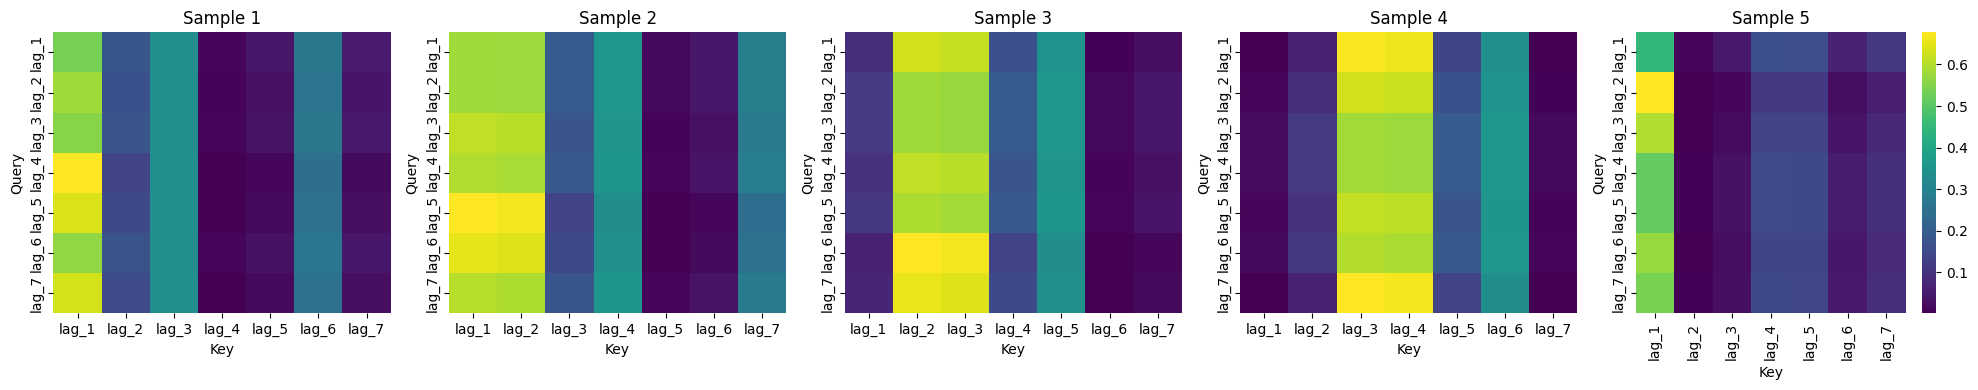

In [72]:
sample = X_test_scaled[:5]
attn_weights = attention_weights_model.predict(sample, verbose=0)   # shape: (5, 7, 7)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    sns.heatmap(
        attn_weights[i],
        ax=axes[i],
        cmap="viridis",
        cbar=(i == 4),
        xticklabels=[f"lag_{j}" for j in range(1, 8)],
        yticklabels=[f"lag_{j}" for j in range(1, 8)]
    )
    axes[i].set_title(f"Sample {i+1}")
    axes[i].set_xlabel("Key")
    axes[i].set_ylabel("Query")

plt.tight_layout()
plt.show()

### 16. Ablation Study

In [73]:
fourier_idx = [0, 1]
rolling_idx = [2, 3, 4, 5]
lag_idx = [6, 7, 8, 9, 10, 11, 12]

all_idx = list(range(X_train_scaled.shape[1]))

print("All features:", all_idx)
print("Fourier:", fourier_idx)
print("Rolling:", rolling_idx)
print("Lags:", lag_idx)

All features: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Fourier: [0, 1]
Rolling: [2, 3, 4, 5]
Lags: [6, 7, 8, 9, 10, 11, 12]


In [74]:
def subset_features(X, keep_idx):
    return X[:, keep_idx]

def build_ffn_multioutput(input_dim_local):
    inputs = keras.Input(shape=(input_dim_local,))
    x = layers.Dense(64, activation="relu")(inputs)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(7)(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )
    return model

def evaluate_macro_metrics(y_true, y_pred):
    rmses = []
    maes = []

    for i in range(7):
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        rmses.append(rmse)
        maes.append(mae)

    return np.mean(rmses), np.mean(maes)

In [75]:
def build_attention_model_with_scores_dynamic(input_dim_local):
    inputs = keras.Input(shape=(input_dim_local,), name="full_input")

    lag = layers.Lambda(lambda x: x[:, -7:], name="lag_slice")(inputs)
    other = layers.Lambda(lambda x: x[:, :-7], name="other_slice")(inputs)

    lag_seq = layers.Reshape((7, 1), name="lag_reshape")(lag)

    Q = layers.Dense(16, name="Q_proj")(lag_seq)
    K = layers.Dense(16, name="K_proj")(lag_seq)
    V = layers.Dense(16, name="V_proj")(lag_seq)

    scores = layers.Lambda(
        lambda x: tf.matmul(x[0], x[1], transpose_b=True) / tf.sqrt(tf.cast(tf.shape(x[0])[-1], tf.float32)),
        name="attention_scores"
    )([Q, K])

    weights = layers.Softmax(axis=-1, name="attention_weights")(scores)

    context = layers.Lambda(
        lambda x: tf.matmul(x[0], x[1]),
        name="attention_context"
    )([weights, V])

    context_flat = layers.Flatten(name="attention_flat")(context)
    concat = layers.Concatenate(name="concat_features")([context_flat, other])

    x = layers.Dense(64, activation="relu", name="hidden")(concat)
    outputs = layers.Dense(7, name="forecast_output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )

    weights_model = keras.Model(inputs=inputs, outputs=weights)

    return model, weights_model

In [76]:
attention_model, attention_weights_model = build_attention_model_with_scores_dynamic(X_train_scaled.shape[1])

attention_model.fit(
    X_train_scaled,
    y_train_np,
    validation_data=(X_val_scaled, y_val_np),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
    verbose=0
)

baseline_preds = attention_model.predict(X_test_scaled, verbose=0)
baseline_rmse, baseline_mae = evaluate_macro_metrics(y_test_np, baseline_preds)

print("Baseline Attention Model")
print("Macro RMSE:", baseline_rmse)
print("Macro MAE:", baseline_mae)

Baseline Attention Model
Macro RMSE: 61.98234083358483
Macro MAE: 48.522103675474575


E0000 00:00:1773731064.119616 8935904 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [77]:
keep_no_fourier = [i for i in all_idx if i not in fourier_idx]

X_train_no_fourier = subset_features(X_train_scaled, keep_no_fourier)
X_val_no_fourier = subset_features(X_val_scaled, keep_no_fourier)
X_test_no_fourier = subset_features(X_test_scaled, keep_no_fourier)

model_no_fourier, _ = build_attention_model_with_scores_dynamic(X_train_no_fourier.shape[1])

model_no_fourier.fit(
    X_train_no_fourier,
    y_train_np,
    validation_data=(X_val_no_fourier, y_val_np),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
    verbose=0
)

pred_no_fourier = model_no_fourier.predict(X_test_no_fourier, verbose=0)
rmse_no_fourier, mae_no_fourier = evaluate_macro_metrics(y_test_np, pred_no_fourier)

print("No Fourier - Macro RMSE:", rmse_no_fourier)
print("No Fourier - Macro MAE:", mae_no_fourier)

No Fourier - Macro RMSE: 70.31091874994753
No Fourier - Macro MAE: 53.89684122545019


E0000 00:00:1773731074.499916 8935904 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [78]:
keep_no_rolling = [i for i in all_idx if i not in rolling_idx]

X_train_no_rolling = subset_features(X_train_scaled, keep_no_rolling)
X_val_no_rolling = subset_features(X_val_scaled, keep_no_rolling)
X_test_no_rolling = subset_features(X_test_scaled, keep_no_rolling)

model_no_rolling, _ = build_attention_model_with_scores_dynamic(X_train_no_rolling.shape[1])

model_no_rolling.fit(
    X_train_no_rolling,
    y_train_np,
    validation_data=(X_val_no_rolling, y_val_np),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
    verbose=0
)

pred_no_rolling = model_no_rolling.predict(X_test_no_rolling, verbose=0)
rmse_no_rolling, mae_no_rolling = evaluate_macro_metrics(y_test_np, pred_no_rolling)

print("No Rolling - Macro RMSE:", rmse_no_rolling)
print("No Rolling - Macro MAE:", mae_no_rolling)

No Rolling - Macro RMSE: 63.39157269397193
No Rolling - Macro MAE: 49.38309062466114


E0000 00:00:1773731084.736194 8935904 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [79]:
keep_no_lags = [i for i in all_idx if i not in lag_idx]

X_train_no_lags = subset_features(X_train_scaled, keep_no_lags)
X_val_no_lags = subset_features(X_val_scaled, keep_no_lags)
X_test_no_lags = subset_features(X_test_scaled, keep_no_lags)

model_no_lags = build_ffn_multioutput(X_train_no_lags.shape[1])

model_no_lags.fit(
    X_train_no_lags,
    y_train_np,
    validation_data=(X_val_no_lags, y_val_np),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
    verbose=0
)

pred_no_lags = model_no_lags.predict(X_test_no_lags, verbose=0)
rmse_no_lags, mae_no_lags = evaluate_macro_metrics(y_test_np, pred_no_lags)

print("No Lags - Macro RMSE:", rmse_no_lags)
print("No Lags - Macro MAE:", mae_no_lags)

No Lags - Macro RMSE: 61.65734662516468
No Lags - Macro MAE: 48.09117778809844


In [80]:
model_no_attention = build_ffn_multioutput(X_train_scaled.shape[1])

model_no_attention.fit(
    X_train_scaled,
    y_train_np,
    validation_data=(X_val_scaled, y_val_np),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
    verbose=0
)

pred_no_attention = model_no_attention.predict(X_test_scaled, verbose=0)
rmse_no_attention, mae_no_attention = evaluate_macro_metrics(y_test_np, pred_no_attention)

print("No Attention - Macro RMSE:", rmse_no_attention)
print("No Attention - Macro MAE:", mae_no_attention)

No Attention - Macro RMSE: 61.48596897553945
No Attention - Macro MAE: 47.97574958288451


E0000 00:00:1773731093.968184 8935904 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [81]:
ablation_df = pd.DataFrame([
    {"model": "Full Attention Model", "RMSE": baseline_rmse, "MAE": baseline_mae},
    {"model": "Remove Fourier", "RMSE": rmse_no_fourier, "MAE": mae_no_fourier},
    {"model": "Remove Rolling", "RMSE": rmse_no_rolling, "MAE": mae_no_rolling},
    {"model": "Remove Lags", "RMSE": rmse_no_lags, "MAE": mae_no_lags},
    {"model": "Remove Attention", "RMSE": rmse_no_attention, "MAE": mae_no_attention},
])

ablation_df["RMSE_degradation"] = ablation_df["RMSE"] - baseline_rmse
ablation_df["MAE_degradation"] = ablation_df["MAE"] - baseline_mae

ablation_df

,model,RMSE,MAE,RMSE_degradation,MAE_degradation
0,Full Attention Model,61.982341,48.522104,0.000000,0.000000
1,Remove Fourier,70.310919,53.896841,8.328578,5.374738
2,Remove Rolling,63.391573,49.383091,1.409232,0.860987
3,Remove Lags,61.657347,48.091178,-0.324994,-0.430926
4,Remove Attention,61.485969,47.975750,-0.496372,-0.546354


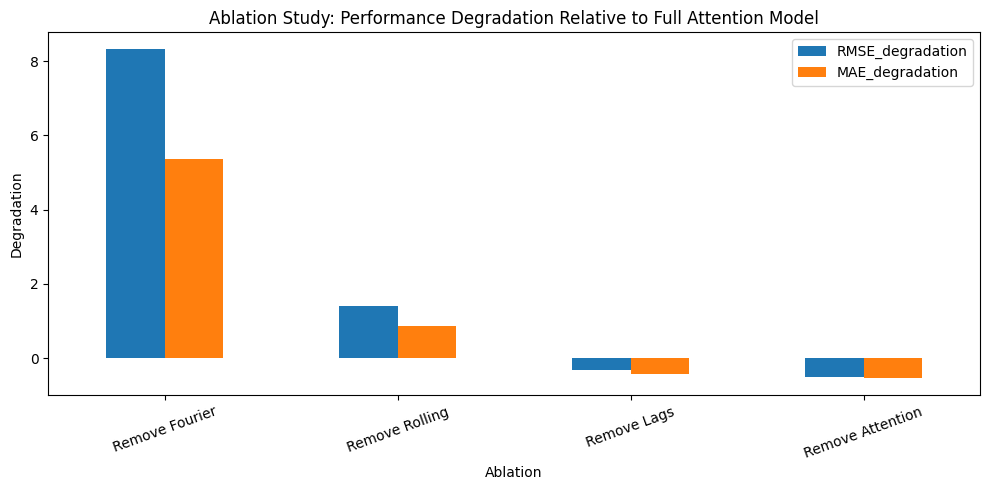

In [82]:
plot_df = ablation_df[ablation_df["model"] != "Full Attention Model"].copy()

plot_df.plot(
    x="model",
    y=["RMSE_degradation", "MAE_degradation"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Ablation Study: Performance Degradation Relative to Full Attention Model")
plt.ylabel("Degradation")
plt.xlabel("Ablation")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

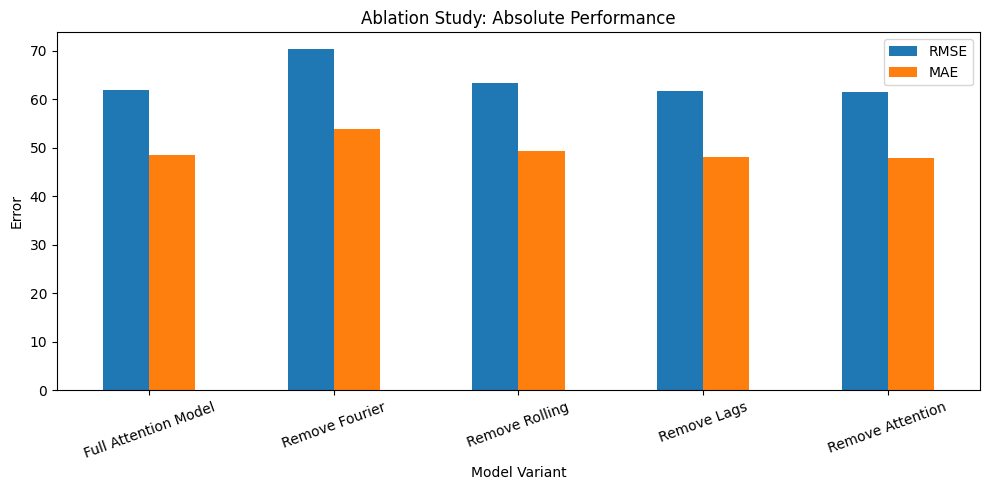

In [83]:
ablation_df.plot(
    x="model",
    y=["RMSE", "MAE"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Ablation Study: Absolute Performance")
plt.ylabel("Error")
plt.xlabel("Model Variant")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Part E: Statistical Analysis and Discussion

In [84]:
from scipy.stats import ttest_rel, t
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [85]:
partB_model = model_mse

In [86]:
pred_multi = partB_model.predict(X_test_scaled, verbose=0)

pred_individual = np.column_stack([
    independent_models[i].predict(X_test_scaled, verbose=0).flatten()
    for i in range(7)
])

pred_multitask_raw = multitask_model.predict(X_test_scaled, verbose=0)
pred_multitask = np.column_stack([p.flatten() for p in pred_multitask_raw])

pred_attention = attention_model.predict(X_test_scaled, verbose=0)

print("Shapes:")
print("y_test_np      :", y_test_np.shape)
print("pred_multi     :", pred_multi.shape)
print("pred_individual:", pred_individual.shape)
print("pred_multitask :", pred_multitask.shape)
print("pred_attention :", pred_attention.shape)

Shapes:
y_test_np      : (347, 7)
pred_multi     : (347, 7)
pred_individual: (347, 7)
pred_multitask : (347, 7)
pred_attention : (347, 7)


In [87]:
mae_multi = np.mean(np.abs(y_test_np - pred_multi), axis=1)
mae_individual = np.mean(np.abs(y_test_np - pred_individual), axis=1)
mae_attention = np.mean(np.abs(y_test_np - pred_attention), axis=1)
mae_multitask = np.mean(np.abs(y_test_np - pred_multitask), axis=1)

print("Daily MAE vector lengths:")
print(len(mae_multi), len(mae_individual), len(mae_attention), len(mae_multitask))

Daily MAE vector lengths:
347 347 347 347


In [88]:
comparisons = {
    "multi-output vs individual": (mae_multi, mae_individual),
    "attention vs multi-output": (mae_attention, mae_multi),
    "multi-output vs multi-task": (mae_multi, mae_multitask),
}

ttest_results = []

for name, (a, b) in comparisons.items():
    diff = a - b
    n = len(diff)

    t_stat, p_value = ttest_rel(a, b)

    mean_diff = np.mean(diff)
    sd_diff = np.std(diff, ddof=1)
    se_diff = sd_diff / np.sqrt(n)
    t_crit = t.ppf(0.975, df=n - 1)

    ci_low = mean_diff - t_crit * se_diff
    ci_high = mean_diff + t_crit * se_diff

    ttest_results.append({
        "comparison": name,
        "mean_diff": mean_diff,
        "t_statistic": t_stat,
        "p_value": p_value,
        "ci_95_low": ci_low,
        "ci_95_high": ci_high
    })

ttest_df = pd.DataFrame(ttest_results)
ttest_df

,comparison,mean_diff,t_statistic,p_value,ci_95_low,ci_95_high
0,multi-output vs individual,-0.020006,-0.116483,0.907337,-0.357815,0.317803
1,attention vs multi-output,0.429656,1.810425,0.071097,-0.037122,0.896434
2,multi-output vs multi-task,-0.594496,-4.742033,0.000003,-0.841074,-0.347918


In [89]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def grouped_error_stats(df, group_col, y_true_cols, y_pred_cols):
    rows = []

    for group_name, g in df.groupby(group_col):
        y_true_g = g[y_true_cols].values
        y_pred_g = g[y_pred_cols].values

        daily_rmse = np.sqrt(np.mean((y_true_g - y_pred_g) ** 2, axis=1))
        daily_mae = np.mean(np.abs(y_true_g - y_pred_g), axis=1)

        rows.append({
            group_col: group_name,
            "RMSE": daily_rmse.mean(),
            "MAE": daily_mae.mean()
        })

    return pd.DataFrame(rows)

def plot_grouped_bar(df, category_col, title):
    plot_df = df.set_index(category_col)[["RMSE", "MAE"]]
    plot_df.plot(kind="bar", figsize=(8, 4))
    plt.title(title)
    plt.ylabel("Error")
    plt.xlabel(category_col)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [90]:
analysis_df = test_df[["date", "solar_t"]].copy().reset_index(drop=True)

for i in range(7):
    analysis_df[f"y_true_t+{i+1}"] = y_test_np[:, i]
    analysis_df[f"y_pred_t+{i+1}"] = pred_multi[:, i]

analysis_df["daily_rmse_avg7"] = np.sqrt(np.mean((y_test_np - pred_multi) ** 2, axis=1))
analysis_df["daily_mae_avg7"] = np.mean(np.abs(y_test_np - pred_multi), axis=1)

analysis_df.head()

,date,solar_t,y_true_t+1,y_pred_t+1,y_true_t+2,y_pred_t+2,y_true_t+3,y_pred_t+3,y_true_t+4,y_pred_t+4,y_true_t+5,y_pred_t+5,y_true_t+6,y_pred_t+6,y_true_t+7,y_pred_t+7,daily_rmse_avg7,daily_mae_avg7
0,2011-01-26,137.692525,100.465418,113.187744,60.668584,113.043877,166.628151,116.589394,82.132143,116.970421,81.416851,118.416916,113.866370,119.303185,148.104861,120.504372,35.421871,31.430289
1,2011-01-30,100.465418,60.668584,118.474686,166.628151,119.345367,82.132143,122.166565,81.416851,122.523613,113.866370,123.416931,148.104861,124.847527,108.520950,126.410553,37.458325,33.846796
2,2011-01-31,60.668584,166.628151,122.061684,82.132143,122.484863,81.416851,125.162605,113.866370,124.854996,148.104861,126.331818,108.520950,127.945374,180.943450,129.534637,36.140979,33.179978
3,2011-02-02,166.628151,82.132143,127.908638,81.416851,128.316772,113.866370,130.430664,148.104861,129.875076,108.520950,131.402481,180.943450,133.480438,187.222140,134.492249,38.653284,35.792133
4,2011-02-03,82.132143,81.416851,126.710960,113.866370,125.481247,148.104861,129.044174,108.520950,129.310745,180.943450,131.437622,187.222140,132.196838,185.396055,133.306015,39.953491,36.197234


In [91]:
months = pd.to_datetime(analysis_df["date"]).dt.month

def month_to_season(m):
    if m in [12, 1, 2]:
        return "winter"
    elif m in [3, 4, 5]:
        return "spring"
    elif m in [6, 7, 8]:
        return "summer"
    else:
        return "autumn"

analysis_df["season"] = months.map(month_to_season)

y_true_cols = [f"y_true_t+{i+1}" for i in range(7)]
y_pred_cols = [f"y_pred_t+{i+1}" for i in range(7)]

season_stats = grouped_error_stats(analysis_df, "season", y_true_cols, y_pred_cols)
season_stats

,season,RMSE,MAE
0,autumn,51.987222,43.990371
1,spring,80.083929,67.598802
2,summer,56.892774,48.835751
3,winter,41.118879,36.499000


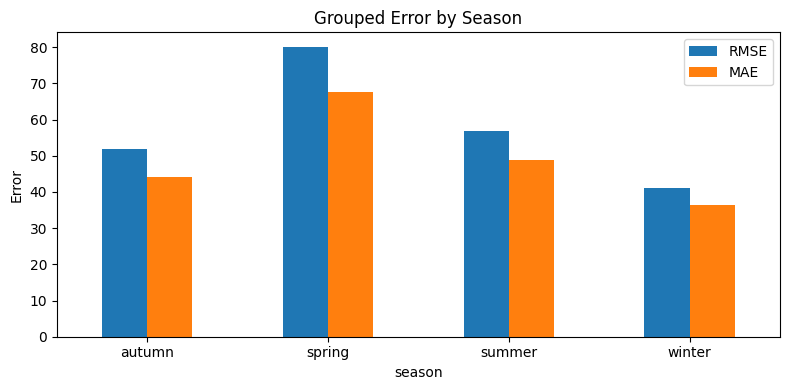

In [92]:
plot_grouped_bar(season_stats, "season", "Grouped Error by Season")

In [93]:
short_true = y_test_np[:, :3]
short_pred = pred_multi[:, :3]

long_true = y_test_np[:, 3:]
long_pred = pred_multi[:, 3:]

horizon_group_df = pd.DataFrame([
    {
        "horizon_group": "short-term",
        "RMSE": rmse(short_true, short_pred),
        "MAE": mae(short_true, short_pred)
    },
    {
        "horizon_group": "long-term",
        "RMSE": rmse(long_true, long_pred),
        "MAE": mae(long_true, long_pred)
    }
])

horizon_group_df

,horizon_group,RMSE,MAE
0,short-term,59.241167,46.321862
1,long-term,63.566012,49.420387


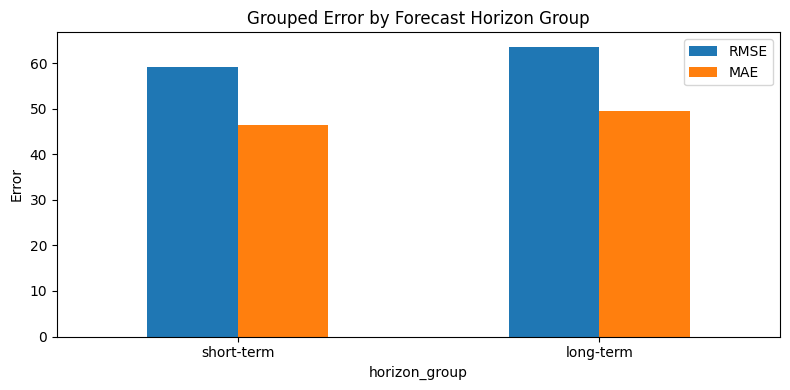

In [94]:
plot_grouped_bar(horizon_group_df, "horizon_group", "Grouped Error by Forecast Horizon Group")

In [95]:
p25 = np.percentile(train_df["solar_t"], 25)
p75 = np.percentile(train_df["solar_t"], 75)

def classify_weather(v):
    if v > p75:
        return "clear"
    elif v < p25:
        return "cloudy"
    else:
        return "mixed"

analysis_df["weather_condition"] = analysis_df["solar_t"].apply(classify_weather)

weather_stats = grouped_error_stats(analysis_df, "weather_condition", y_true_cols, y_pred_cols)
weather_stats

,weather_condition,RMSE,MAE
0,clear,71.518811,61.212493
1,cloudy,39.740205,34.689512
2,mixed,57.817102,49.219880


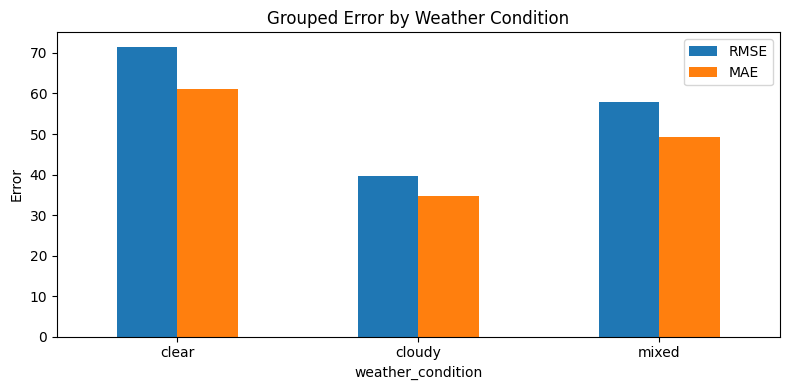

In [96]:
plot_grouped_bar(weather_stats, "weather_condition", "Grouped Error by Weather Condition")

In [97]:
p33 = np.percentile(train_df["solar_t"], 33.3333)
p67 = np.percentile(train_df["solar_t"], 66.6667)

def classify_magnitude(v):
    if v < p33:
        return "low"
    elif v < p67:
        return "medium"
    else:
        return "high"

analysis_df["radiation_magnitude"] = analysis_df["solar_t"].apply(classify_magnitude)

magnitude_stats = grouped_error_stats(analysis_df, "radiation_magnitude", y_true_cols, y_pred_cols)
magnitude_stats

,radiation_magnitude,RMSE,MAE
0,high,71.237022,60.634162
1,low,39.953195,34.634083
2,medium,58.445600,49.984034


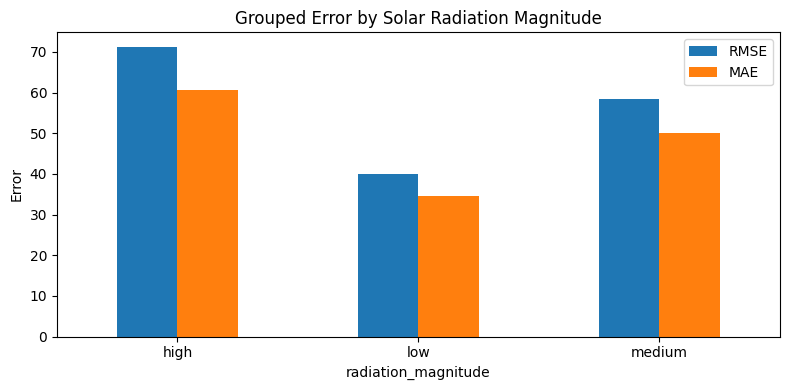

In [98]:
plot_grouped_bar(magnitude_stats, "radiation_magnitude", "Grouped Error by Solar Radiation Magnitude")

In [99]:
analysis_df[[
    "date", "solar_t", "season", "weather_condition", "radiation_magnitude",
    "daily_rmse_avg7", "daily_mae_avg7"
]].head()

,date,solar_t,season,weather_condition,radiation_magnitude,daily_rmse_avg7,daily_mae_avg7
0,2011-01-26,137.692525,winter,mixed,medium,35.421871,31.430289
1,2011-01-30,100.465418,winter,cloudy,low,37.458325,33.846796
2,2011-01-31,60.668584,winter,cloudy,low,36.140979,33.179978
3,2011-02-02,166.628151,winter,mixed,medium,38.653284,35.792133
4,2011-02-03,82.132143,winter,cloudy,low,39.953491,36.197234


## Code to save models

In [100]:
from tensorflow import keras
import joblib
from pathlib import Path

MODEL_DIR = Path("models")
SCALER_DIR = Path("scalers")

MODEL_DIR.mkdir(exist_ok=True)
SCALER_DIR.mkdir(exist_ok=True)

# Part B
model_mse.save(MODEL_DIR / "partB_model_mse.keras")

# Part C
for i, model in enumerate(independent_models, start=1):
    model.save(MODEL_DIR / f"independent_model_t{i}.keras")

# Part C
previous_model.save(MODEL_DIR / "sequential_final_model.keras")

# Part C
multitask_model.save(MODEL_DIR / "multitask_model.keras")

# Part D
mc_model.save(MODEL_DIR / "mc_dropout_model.keras")
attention_model.save(MODEL_DIR / "attention_model.keras")

# scaler
joblib.dump(scaler, SCALER_DIR / "feature_scaler.pkl")

print("Models and scaler saved.")

Models and scaler saved.


## Evaluation Cell

Hidden files found: ["/Users/pulkitjain/Documents/Documents - Pulkit's MacBook Pro/UNSW Study/Term 1/COMP9414/Assignment 1/datasets/daily_solar_1996.csv", "/Users/pulkitjain/Documents/Documents - Pulkit's MacBook Pro/UNSW Study/Term 1/COMP9414/Assignment 1/datasets/daily_solar_1997.csv", "/Users/pulkitjain/Documents/Documents - Pulkit's MacBook Pro/UNSW Study/Term 1/COMP9414/Assignment 1/datasets/daily_solar_1998.csv", "/Users/pulkitjain/Documents/Documents - Pulkit's MacBook Pro/UNSW Study/Term 1/COMP9414/Assignment 1/datasets/daily_solar_1999.csv", "/Users/pulkitjain/Documents/Documents - Pulkit's MacBook Pro/UNSW Study/Term 1/COMP9414/Assignment 1/datasets/daily_solar_2000.csv", "/Users/pulkitjain/Documents/Documents - Pulkit's MacBook Pro/UNSW Study/Term 1/COMP9414/Assignment 1/datasets/daily_solar_2001.csv", "/Users/pulkitjain/Documents/Documents - Pulkit's MacBook Pro/UNSW Study/Term 1/COMP9414/Assignment 1/datasets/daily_solar_2002.csv", "/Users/pulkitjain/Documents/Documents - 

E0000 00:00:1773731109.734714 8935904 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


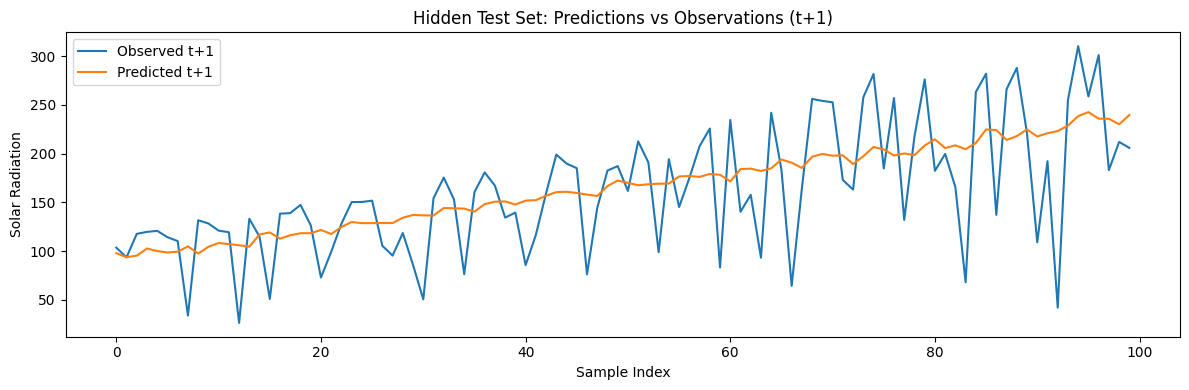

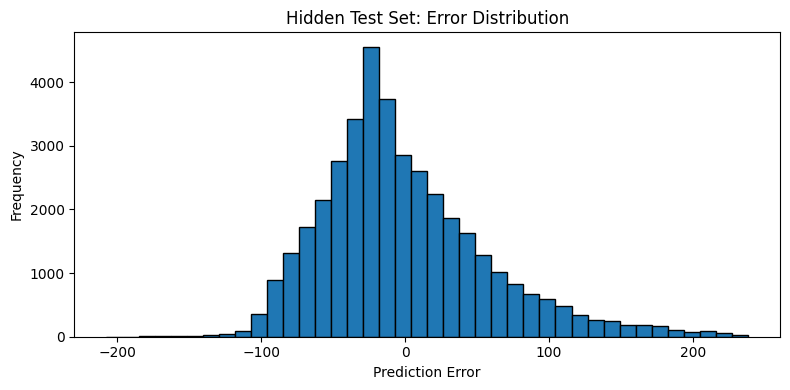

,model,macro_RMSE,macro_MAE
0,PartB_MultiOutput,57.865424,44.571409
1,Attention,58.027509,44.874639


In [103]:
import glob
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from tensorflow import keras
from sklearn.metrics import mean_squared_error, mean_absolute_error

BASE_DIR = Path.cwd()
HIDDEN_DIR = BASE_DIR / "datasets"
# HIDDEN_DIR = BASE_DIR / "hidden_data"
MODEL_DIR = BASE_DIR / "models"
SCALER_PATH = BASE_DIR / "scalers" / "feature_scaler.pkl"

def weighted_mse(y_true, y_pred):
    weights = tf.constant([1 / np.sqrt(k) for k in range(1, 8)], dtype=tf.float32)
    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

hidden_files = sorted(glob.glob(str(HIDDEN_DIR / "daily_solar_*.csv")))
print("Hidden files found:", hidden_files)

if len(hidden_files) == 0:
    raise FileNotFoundError(f"No CSV files found in {HIDDEN_DIR}")

hidden_dfs = []
for file in hidden_files:
    df = pd.read_csv(file)
    hidden_dfs.append(df)

hidden_raw = pd.concat(hidden_dfs, ignore_index=True)
hidden_raw["date"] = pd.to_datetime(hidden_raw["date"])
hidden_raw = hidden_raw.sort_values("date").reset_index(drop=True)

print("Hidden raw shape:", hidden_raw.shape)
hidden_raw.head()

hidden_clean = hidden_raw[hidden_raw["bad_quality"] == 0].copy()
hidden_clean = hidden_clean.sort_values("date").reset_index(drop=True)

hidden_clean["day_of_year"] = hidden_clean["date"].dt.dayofyear
hidden_clean["is_leap_year"] = hidden_clean["date"].dt.is_leap_year.astype(int)
hidden_clean["days_in_year"] = np.where(hidden_clean["is_leap_year"] == 1, 366, 365)

hidden_clean["day_sin"] = np.sin(2 * np.pi * hidden_clean["day_of_year"] / hidden_clean["days_in_year"])
hidden_clean["day_cos"] = np.cos(2 * np.pi * hidden_clean["day_of_year"] / hidden_clean["days_in_year"])

hidden_clean["solar_mean_7d"] = hidden_clean["solar_t"].rolling(window=7, min_periods=7).mean()
hidden_clean["solar_std_7d"]  = hidden_clean["solar_t"].rolling(window=7, min_periods=7).std(ddof=1)
hidden_clean["solar_min_7d"]  = hidden_clean["solar_t"].rolling(window=7, min_periods=7).min()
hidden_clean["solar_max_7d"]  = hidden_clean["solar_t"].rolling(window=7, min_periods=7).max()

for k in range(1, 8):
    hidden_clean[f"lag_{k}"] = hidden_clean["solar_t"].shift(k)

for k in range(1, 8):
    hidden_clean[f"target_t_plus_{k}"] = hidden_clean["solar_t"].shift(-k)

feature_cols = [
    "day_sin",
    "day_cos",
    "solar_mean_7d",
    "solar_std_7d",
    "solar_min_7d",
    "solar_max_7d",
] + [f"lag_{k}" for k in range(1, 8)]

target_cols = [f"target_t_plus_{k}" for k in range(1, 8)]

hidden_model_df = hidden_clean.dropna(subset=feature_cols + target_cols).copy().reset_index(drop=True)

print("Hidden processed shape:", hidden_model_df.shape)
hidden_model_df.head()

X_hidden = hidden_model_df[feature_cols].copy()
y_hidden = hidden_model_df[target_cols].copy().values

scaler_loaded = joblib.load(SCALER_PATH)
X_hidden_scaled = scaler_loaded.transform(X_hidden)

print("X_hidden_scaled:", X_hidden_scaled.shape)
print("y_hidden:", y_hidden.shape)

partB_model = keras.models.load_model(
    MODEL_DIR / "partB_model_mse.keras",
    custom_objects={"weighted_mse": weighted_mse},
    compile=False
)

independent_models_loaded = [
    keras.models.load_model(MODEL_DIR / f"independent_model_t{i}.keras", compile=False)
    for i in range(1, 8)
]

sequential_model_loaded = keras.models.load_model(
    MODEL_DIR / "sequential_final_model.keras",
    compile=False
)

multitask_model_loaded = keras.models.load_model(
    MODEL_DIR / "multitask_model.keras",
    compile=False
)

mc_model_loaded = keras.models.load_model(
    MODEL_DIR / "mc_dropout_model.keras",
    compile=False
)

attention_model_loaded = attention_model

feature_model_path = MODEL_DIR / "feature_extraction_t7_model.keras"
if feature_model_path.exists():
    feature_model_loaded = keras.models.load_model(feature_model_path, compile=False)
    print("Feature extraction model loaded.")
else:
    feature_model_loaded = None
    print("Feature extraction model not found, skipping.")

print("All required models are ready.")

pred_hidden = partB_model.predict(X_hidden_scaled, verbose=0)

results_hidden = []

for i in range(7):
    rmse_i = np.sqrt(mean_squared_error(y_hidden[:, i], pred_hidden[:, i]))
    mae_i = mean_absolute_error(y_hidden[:, i], pred_hidden[:, i])

    results_hidden.append({
        "horizon": f"t+{i+1}",
        "RMSE": rmse_i,
        "MAE": mae_i
    })

hidden_metrics_df = pd.DataFrame(results_hidden)

macro_row = pd.DataFrame([{
    "horizon": "macro_avg",
    "RMSE": hidden_metrics_df["RMSE"].mean(),
    "MAE": hidden_metrics_df["MAE"].mean()
}])

hidden_metrics_df = pd.concat([hidden_metrics_df, macro_row], ignore_index=True)
hidden_metrics_df

plt.figure(figsize=(12, 4))
plt.plot(y_hidden[:100, 0], label="Observed t+1")
plt.plot(pred_hidden[:100, 0], label="Predicted t+1")
plt.title("Hidden Test Set: Predictions vs Observations (t+1)")
plt.xlabel("Sample Index")
plt.ylabel("Solar Radiation")
plt.legend()
plt.tight_layout()
plt.show()

errors_hidden = (pred_hidden - y_hidden).flatten()

plt.figure(figsize=(8, 4))
plt.hist(errors_hidden, bins=40, edgecolor="black")
plt.title("Hidden Test Set: Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

pred_attention_hidden = attention_model_loaded.predict(X_hidden_scaled, verbose=0)

compare_models_df = []

for name, pred in {
    "PartB_MultiOutput": pred_hidden,
    "Attention": pred_attention_hidden
}.items():
    rmses = []
    maes = []

    for i in range(7):
        rmses.append(np.sqrt(mean_squared_error(y_hidden[:, i], pred[:, i])))
        maes.append(mean_absolute_error(y_hidden[:, i], pred[:, i]))

    compare_models_df.append({
        "model": name,
        "macro_RMSE": np.mean(rmses),
        "macro_MAE": np.mean(maes)
    })

compare_models_df = pd.DataFrame(compare_models_df)
compare_models_df